# 5. Τμηματοποίηση της Αγοράς και Ερμηνευτικά Συμπεράσματα  
## (Market Segmentation & Insights for the Used Car Market in Attica)

Στο παρόν notebook πραγματοποιείται το πέμπτο στάδιο της εμπειρικής ανάλυσης της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική για την περίοδο 2021–2026.

Μετά την ολοκλήρωση των προηγούμενων σταδίων, τα οποία επικεντρώθηκαν στον καθαρισμό των δεδομένων, τη διερευνητική ανάλυση, τη μοντελοποίηση πρόβλεψης τιμής, την αξιολόγηση του τελικού μοντέλου και τη σύνθεση των βασικών αποτελεσμάτων, η παρούσα ενότητα μετατοπίζει το επίκεντρο από την **πρόβλεψη ατομικής τιμής** στη **συνολική ανάλυση της δομής της αγοράς**.

Στόχος του notebook είναι:

- η περιγραφική αποτύπωση της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική,
- η δημιουργία και αξιοποίηση **price segments** για τη μελέτη διακριτών υποαγορών,
- η σύγκριση βασικών κατηγοριών όπως το καύσιμο, ο κατασκευαστής, η μετάδοση και το έτος εγγραφής,
- και η εξαγωγή **ερμηνευτικών συμπερασμάτων** που μπορούν να αξιοποιηθούν τόσο στη συγγραφή της πτυχιακής όσο και σε μελλοντικά dashboard-ready outputs.

Η ανάλυση βασίζεται κυρίως στο **cleaned analytical dataset**, ώστε οι συγκρίσεις να παραμένουν ερμηνεύσιμες σε επίπεδο αγοράς και να μην περιορίζονται στη λογική του model-ready transformation.

## Μεθοδολογικό Πλαίσιο

Η παρούσα ανάλυση ακολουθεί διαδοχικά στάδια, με στόχο τη συστηματική διερεύνηση της δομής της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική.

Ειδικότερα, το notebook οργανώνεται ως εξής:

1. φόρτωση και έλεγχος του cleaned analytical dataset,
2. ορισμός του analytical sample και έλεγχος βασικών μεταβλητών,
3. παραγωγή περιγραφικών στατιστικών σε επίπεδο αγοράς,
4. δημιουργία price segments για την ανάλυση διακριτών υποαγορών,
5. σύγκριση βασικών κατηγοριών όπως το καύσιμο, ο κατασκευαστής, η μετάδοση, το έτος εγγραφής και η περιοχή,
6. εξαγωγή ερμηνευτικών συμπερασμάτων για τη δομή της αγοράς,
7. αποθήκευση των βασικών πινάκων και γραφημάτων σε φακέλους κατάλληλους για reproducible workflow.

Η προσέγγιση αυτή επιτρέπει τη μετάβαση από την ατομική πρόβλεψη τιμής σε μία πιο συνολική, περιγραφική και ερμηνευτική θεώρηση της αγοράς.

In [1]:
# ===============================
# Notebook 5 - Βασικά imports και ρυθμίσεις
# ===============================

# Βασικές βιβλιοθήκες Python
from pathlib import Path
import warnings
import random

# Βιβλιοθήκες ανάλυσης δεδομένων
import numpy as np
import pandas as pd

# Βιβλιοθήκες οπτικοποίησης
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Γενικές ρυθμίσεις
# ===============================

# Απόκρυψη μη κρίσιμων warnings για πιο καθαρό output
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Ρυθμίσεις εμφάνισης pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

# Ρυθμίσεις γραφημάτων
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print("Το περιβάλλον του Notebook 5 ρυθμίστηκε επιτυχώς.")

Το περιβάλλον του Notebook 5 ρυθμίστηκε επιτυχώς.


In [2]:
# ===============================
# Notebook 5 - Helper functions και paths
# ===============================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το root του project αναζητώντας βασικούς φακέλους/αρχεία.
    """
    current = start_path.resolve()

    for path in [current] + list(current.parents):
        has_data = (path / "data").exists()
        has_notebooks = (path / "notebooks").exists()
        has_readme = (path / "README.md").exists()

        if has_data and has_notebooks and has_readme:
            return path

    raise FileNotFoundError("Δεν βρέθηκε το root του project.")


def save_plot(filename: str, dpi: int = 300) -> None:
    """
    Αποθηκεύει το τρέχον matplotlib figure στον φάκελο plots/.
    """
    output_path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Το γράφημα αποθηκεύτηκε στο: {output_path}")


def export_csv(df: pd.DataFrame, filename: str) -> None:
    """
    Αποθηκεύει DataFrame ως CSV στον φάκελο data/processed/.
    """
    output_path = PROCESSED_DIR / filename
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Το αρχείο CSV αποθηκεύτηκε στο: {output_path}")


# Εντοπισμός root φακέλου project
PROJECT_ROOT = find_project_root(Path.cwd())

# Ορισμός βασικών φακέλων
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PLOTS_DIR = PROJECT_ROOT / "plots"

# Δημιουργία φακέλων αν δεν υπάρχουν
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data dir: {PROCESSED_DIR}")
print(f"Plots dir: {PLOTS_DIR}")

Project root: C:\Users\athin\Desktop\Car-Market-Analysis-Attica
Processed data dir: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed
Plots dir: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots


## Φόρτωση του Καθαρισμένου Analytical Dataset

Στο παρόν στάδιο φορτώνεται το βασικό cleaned analytical dataset του project, το οποίο θα χρησιμοποιηθεί για την περιγραφική και συγκριτική ανάλυση της αγοράς.

Η επιλογή αυτή είναι σκόπιμη, καθώς το συγκεκριμένο dataset διατηρεί τις βασικές μεταβλητές σε ερμηνεύσιμη μορφή και είναι καταλληλότερο για market-level analysis σε σχέση με την model-ready εκδοχή που χρησιμοποιήθηκε στα προηγούμενα στάδια μοντελοποίησης.

In [3]:
# ===============================
# Notebook 5 - Φόρτωση cleaned analytical dataset
# ===============================

# Πιθανή βασική διαδρομή του cleaned dataset
cleaned_data_path = PROCESSED_DIR / "cleaned_car_data.csv"

# Έλεγχος ότι το αρχείο υπάρχει
if not cleaned_data_path.exists():
    raise FileNotFoundError(
        f"Δεν βρέθηκε το αρχείο: {cleaned_data_path}\n"
        "Έλεγξε αν υπάρχει το cleaned_car_data.csv στον φάκελο data/processed/."
    )

# Φόρτωση dataset
df = pd.read_csv(cleaned_data_path)

# Βασικός έλεγχος φόρτωσης
print(f"Το dataset φορτώθηκε επιτυχώς από: {cleaned_data_path}")
print(f"Σχήμα dataset: {df.shape[0]:,} γραμμές x {df.shape[1]:,} στήλες")

# Προβολή ονομάτων στηλών
print("\nΟνόματα στηλών:")
print(df.columns.tolist())

# Πρώτη επισκόπηση δεδομένων
display(df.head())

# Συνοπτικός έλεγχος τύπων και missing values
print("\nΣυνοπτική πληροφορία dataset:")
df.info()

Το dataset φορτώθηκε επιτυχώς από: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\cleaned_car_data.csv
Σχήμα dataset: 8,933 γραμμές x 20 στήλες

Ονόματα στηλών:
['Α/Α', 'Κατασκευαστής', 'Τύπος', 'Εγγραφή', 'Κυβικά', 'Ιπποδύναμη', 'Καύσιμο', 'Μετάδοση', 'Χιλιόμετρα', 'Τιμή', 'Κατάσταση', 'Περιγραφή', 'Περιοχή', 'Διεύθυνση', 'Σειρά Scraping', 'Ιστοσελίδα', 'Φωτογραφία 1', 'Φωτογραφία 2', 'Φωτογραφία 3', 'Ηλικία']


,Α/Α,Κατασκευαστής,Τύπος,Εγγραφή,Κυβικά,Ιπποδύναμη,Καύσιμο,Μετάδοση,Χιλιόμετρα,Τιμή,Κατάσταση,Περιγραφή,Περιοχή,Διεύθυνση,Σειρά Scraping,Ιστοσελίδα,Φωτογραφία 1,Φωτογραφία 2,Φωτογραφία 3,Ηλικία
0,1,Audi,Q3,"2,025.00","1,500.00",150.00,Βενζίνη,Αυτόματο,"10,500.00","34,900.00",Μεταχειρισμένο,Q3 Advanced Plus 35 TFSI 150 hp S tronic,ΚΗΦΙΣΙΑ 14561,ΚΗΦΙΣΙΑ Ν. ΑΤΤΙΚΗΣ 14561,1769681066-1,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51909142_i_n.jpg,NaN,NaN,1.00
1,2,Toyota,Yaris Cross,"2,025.00","1,500.00",116.00,Υβριδικό Βενζίνης,Αυτόματο,"10,018.00","25,990.00",Μεταχειρισμένο,1.5-116ps-style!!,ΝΕΑ ΙΩΝΙΑ 14235,ΝΕΑ ΙΩΝΙΑ Ν. ΑΤΤΙΚΗΣ 14235,1769681066-2,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51329883_0_n.jpg,NaN,NaN,1.00
2,3,Peugeot,2008,"2,025.00","1,200.00",145.00,Υβριδικό Βενζίνης,Αυτόματο,"3,000.00","26,500.00",Μεταχειρισμένο,"Hybrid Allure - ΕΡΓΟΣΤΑΣΙΑΚΗ ΕΓΓΥΗΣΗ 5 ΕΤΗ, 30...",ΚΗΦΙΣΙΑ 14562,ΚΗΦΙΣΙΑ Ν. ΑΤΤΙΚΗΣ 14562,1769681066-3,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51432222_0_n.jpg,NaN,NaN,1.00
3,4,Peugeot,2008,"2,025.00","1,200.00",145.00,Υβριδικό Βενζίνης,Αυτόματο,"2,900.00","26,500.00",Μεταχειρισμένο,2008 Allure Hybrid Εργ. Εγγύηση 5 έτη - Μόνο 3...,ΝΕΑ ΕΡΥΘΡΑΙA 14671,ΝΕΑ ΕΡΥΘΡΑΙA Ν. ΑΤΤΙΚΗΣ 14671 ΝΕΑ ΕΡΥΘΡΑΙΑ,1769681066-4,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51689355_0_n.jpg,NaN,NaN,1.00
4,5,Beev,ΒEEV-6,"2,025.00",NaN,4.00,Ηλεκτρικό,Αυτόματο,0.00,"10,900.00",Καινούργιο,ΒEEV-6 4P,ΓΛΥΚΑ ΝΕΡΑ 15354,ΓΛΥΚΑ ΝΕΡΑ Ν. ΑΤΤΙΚΗΣ 15354,1769681066-5,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/48676062_b_n.jpg,NaN,NaN,1.00



Συνοπτική πληροφορία dataset:
<class 'pandas.DataFrame'>
RangeIndex: 8933 entries, 0 to 8932
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Α/Α             8933 non-null   int64  
 1   Κατασκευαστής   8933 non-null   str    
 2   Τύπος           8933 non-null   str    
 3   Εγγραφή         8933 non-null   float64
 4   Κυβικά          8164 non-null   float64
 5   Ιπποδύναμη      8933 non-null   float64
 6   Καύσιμο         8933 non-null   str    
 7   Μετάδοση        8933 non-null   str    
 8   Χιλιόμετρα      8931 non-null   float64
 9   Τιμή            8933 non-null   float64
 10  Κατάσταση       8933 non-null   str    
 11  Περιγραφή       8440 non-null   str    
 12  Περιοχή         8933 non-null   str    
 13  Διεύθυνση       8933 non-null   str    
 14  Σειρά Scraping  8933 non-null   str    
 15  Ιστοσελίδα      8933 non-null   str    
 16  Φωτογραφία 1    8933 non-null   str    
 17  Φωτογραφία 2 

## Αρχικός Έλεγχος Δομής και Επιλογή Μεταβλητών

Η πρώτη επισκόπηση του dataset δείχνει ότι το αρχείο περιλαμβάνει τόσο βασικές μεταβλητές ανάλυσης της αγοράς όσο και πρόσθετα πληροφοριακά πεδία που σχετίζονται με τη διαδικασία συλλογής των αγγελιών.

Για τους σκοπούς του παρόντος notebook, δεν είναι απαραίτητο να χρησιμοποιηθούν όλα τα διαθέσιμα πεδία. Αντίθετα, απαιτείται ο ορισμός ενός πιο στοχευμένου analytical subset, το οποίο θα περιλαμβάνει μόνο τις μεταβλητές που είναι ουσιαστικές για τη μελέτη της δομής της αγοράς και της διαφοροποίησης των τιμών.

Στο στάδιο αυτό θα πραγματοποιηθούν:

- έλεγχος της δομής των βασικών μεταβλητών,
- επιλογή των μεταβλητών που θα χρησιμοποιηθούν στην market-level analysis,
- και προετοιμασία ενός καθαρού analytical dataframe κατάλληλου για περιγραφική ανάλυση, τμηματοποίηση και συγκριτικά ευρήματα.

In [4]:
# ===============================
# Notebook 5 - Δημιουργία analytical subset
# ===============================

# Αντιστοίχιση βασικών ελληνικών στηλών σε αγγλικά snake_case
column_mapping = {
    "Κατασκευαστής": "make",
    "Τύπος": "model",
    "Εγγραφή": "registration_year",
    "Κυβικά": "engine_size",
    "Ιπποδύναμη": "horsepower",
    "Καύσιμο": "fuel_type",
    "Μετάδοση": "transmission",
    "Χιλιόμετρα": "mileage",
    "Τιμή": "price",
    "Κατάσταση": "condition",
    "Περιοχή": "region",
    "Ηλικία": "age"
}

# Έλεγχος ότι υπάρχουν όλες οι βασικές στήλες που θέλουμε
missing_columns = [col for col in column_mapping if col not in df.columns]
if missing_columns:
    raise KeyError(
        f"Λείπουν οι παρακάτω βασικές στήλες από το dataset: {missing_columns}"
    )

# Μετονομασία των βασικών στηλών
analysis_df = df.rename(columns=column_mapping).copy()

# Επιλογή μόνο των μεταβλητών που χρειάζονται για market-level analysis
selected_columns = [
    "make",
    "model",
    "registration_year",
    "engine_size",
    "horsepower",
    "fuel_type",
    "transmission",
    "mileage",
    "price",
    "condition",
    "region",
    "age"
]

analysis_df = analysis_df[selected_columns].copy()

# Κρατάμε μόνο μεταχειρισμένα οχήματα, αφού το notebook αφορά used car market
analysis_df = analysis_df.loc[analysis_df["condition"] == "Μεταχειρισμένο"].copy()

# Μετατροπή αριθμητικών πεδίων σε numeric μορφή
numeric_columns = [
    "registration_year",
    "engine_size",
    "horsepower",
    "mileage",
    "price",
    "age"
]

for col in numeric_columns:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

# Βασικός έλεγχος του analytical subset
print("Το analytical subset δημιουργήθηκε επιτυχώς.")
print(f"Σχήμα analysis_df: {analysis_df.shape[0]:,} γραμμές x {analysis_df.shape[1]:,} στήλες")

print("\nΠρώτες γραμμές του analysis_df:")
display(analysis_df.head())

print("\nMissing values ανά μεταβλητή:")
display(analysis_df.isna().sum().sort_values(ascending=False))

print("\nΚατανομή της μεταβλητής condition μετά το φιλτράρισμα:")
display(analysis_df["condition"].value_counts(dropna=False))

Το analytical subset δημιουργήθηκε επιτυχώς.
Σχήμα analysis_df: 8,296 γραμμές x 12 στήλες

Πρώτες γραμμές του analysis_df:


,make,model,registration_year,engine_size,horsepower,fuel_type,transmission,mileage,price,condition,region,age
0,Audi,Q3,"2,025.00","1,500.00",150.00,Βενζίνη,Αυτόματο,"10,500.00","34,900.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14561,1.00
1,Toyota,Yaris Cross,"2,025.00","1,500.00",116.00,Υβριδικό Βενζίνης,Αυτόματο,"10,018.00","25,990.00",Μεταχειρισμένο,ΝΕΑ ΙΩΝΙΑ 14235,1.00
2,Peugeot,2008,"2,025.00","1,200.00",145.00,Υβριδικό Βενζίνης,Αυτόματο,"3,000.00","26,500.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14562,1.00
3,Peugeot,2008,"2,025.00","1,200.00",145.00,Υβριδικό Βενζίνης,Αυτόματο,"2,900.00","26,500.00",Μεταχειρισμένο,ΝΕΑ ΕΡΥΘΡΑΙA 14671,1.00
6,Opel,Grandland (X),"2,025.00","1,200.00",145.00,Υβριδικό Βενζίνης,Αυτόματο,"6,900.00","34,900.00",Μεταχειρισμένο,ΑΘΗΝΑ 11143,1.00



Missing values ανά μεταβλητή:


engine_size          652
mileage                2
model                  0
make                   0
registration_year      0
horsepower             0
fuel_type              0
transmission           0
price                  0
condition              0
region                 0
age                    0
dtype: int64


Κατανομή της μεταβλητής condition μετά το φιλτράρισμα:


condition
Μεταχειρισμένο    8296
Name: count, dtype: int64

## Έλεγχος Ποιότητας του Analytical Sample

Μετά τον αρχικό ορισμό του analytical subset, απαιτείται ένας πιο στοχευμένος έλεγχος της ποιότητας του δείγματος που θα χρησιμοποιηθεί στην ανάλυση.

Ο έλεγχος αυτός είναι σημαντικός, διότι η εγκυρότητα των περιγραφικών στατιστικών, της τμηματοποίησης της αγοράς και των συγκριτικών αποτελεσμάτων εξαρτάται από το κατά πόσο οι βασικές μεταβλητές είναι επαρκώς πλήρεις και αναλυτικά αξιοποιήσιμες.

Ιδιαίτερη έμφαση θα δοθεί:

- στον εντοπισμό ελλιπών τιμών στις κύριες μεταβλητές,
- στην αποτίμηση του μεγέθους της απώλειας πληροφορίας,
- και στην τεκμηρίωση του αν απαιτείται περαιτέρω φιλτράρισμα ή αν το δείγμα μπορεί να χρησιμοποιηθεί όπως είναι για τα επόμενα στάδια της ανάλυσης.

In [5]:
# ===============================
# Notebook 5 - Πίνακας ελλιπών τιμών και quality summary
# ===============================

# Υπολογισμός missing counts και missing percentages
missing_summary = (
    analysis_df.isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["variable", "missing_count"]
missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(analysis_df) * 100
).round(2)

# Ταξινόμηση από τη μεγαλύτερη προς τη μικρότερη έλλειψη
missing_summary = missing_summary.sort_values(
    by=["missing_count", "variable"],
    ascending=[False, True]
).reset_index(drop=True)

print("Πίνακας ελλιπών τιμών στο analytical sample:")
display(missing_summary)

# Export του πίνακα για reproducibility
export_csv(missing_summary, "notebook5_missing_summary.csv")

# Σύντομο quality summary
n_rows = len(analysis_df)
n_cols = analysis_df.shape[1]
n_complete_rows = analysis_df.dropna().shape[0]
complete_rows_pct = round(n_complete_rows / n_rows * 100, 2)

print("\nΣυνοπτικός έλεγχος ποιότητας δείγματος:")
print(f"- Παρατηρήσεις: {n_rows:,}")
print(f"- Μεταβλητές: {n_cols}")
print(f"- Πλήρεις γραμμές χωρίς κανένα missing: {n_complete_rows:,} ({complete_rows_pct}%)")

# Μεταβλητές με τουλάχιστον ένα missing
variables_with_missing = missing_summary.loc[
    missing_summary["missing_count"] > 0, "variable"
].tolist()

print(f"- Μεταβλητές με missing values: {variables_with_missing}")

Πίνακας ελλιπών τιμών στο analytical sample:


,variable,missing_count,missing_pct
0,engine_size,652,7.86
1,mileage,2,0.02
2,age,0,0.00
3,condition,0,0.00
4,fuel_type,0,0.00
5,horsepower,0,0.00
6,make,0,0.00
7,model,0,0.00
8,price,0,0.00
9,region,0,0.00


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_missing_summary.csv

Συνοπτικός έλεγχος ποιότητας δείγματος:
- Παρατηρήσεις: 8,296
- Μεταβλητές: 12
- Πλήρεις γραμμές χωρίς κανένα missing: 7,644 (92.14%)
- Μεταβλητές με missing values: ['engine_size', 'mileage']


## Ερμηνεία του Ελέγχου Ποιότητας

Ο έλεγχος ποιότητας δείχνει ότι το analytical sample είναι επαρκώς πλήρες για να χρησιμοποιηθεί στα επόμενα στάδια της ανάλυσης χωρίς άμεσο ανάγκη εκτεταμένου πρόσθετου φιλτραρίσματος.

Ειδικότερα, η μεγάλη πλειονότητα των βασικών μεταβλητών δεν παρουσιάζει ελλιπείς τιμές, ενώ το μόνο ουσιαστικό missingness εντοπίζεται στη μεταβλητή `engine_size`. Η μεταβλητή `mileage` εμφανίζει πρακτικά αμελητέα απώλεια πληροφορίας.

Με βάση τα παραπάνω, το δείγμα μπορεί να διατηρηθεί **ως έχει** για τη γενική περιγραφική ανάλυση και την τμηματοποίηση της αγοράς. Σε επιμέρους συγκριτικές αναλύσεις όπου η `engine_size` ή η `mileage` χρησιμοποιούνται άμεσα, η διαχείριση των missing values θα γίνει στοχευμένα και κατά περίπτωση, ώστε να αποφεύγεται η άσκοπη μείωση του συνολικού δείγματος.

## Περιγραφική Επισκόπηση της Αγοράς

Αφού ορίστηκε και αξιολογήθηκε το analytical sample, το επόμενο στάδιο αφορά τη συνοπτική περιγραφική αποτύπωση της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική.

Στόχος της ενότητας αυτής είναι να παρουσιαστούν τα βασικά χαρακτηριστικά της αγοράς σε επίπεδο συνολικού δείγματος, πριν από τη δημιουργία price segments και τις επιμέρους συγκριτικές αναλύσεις.

Ειδικότερα, θα εξεταστούν:

- το μέγεθος και η βασική σύνθεση του δείγματος,
- η κατανομή της τιμής,
- η κατανομή βασικών αριθμητικών χαρακτηριστικών όπως τα χιλιόμετρα, η ηλικία, η ιπποδύναμη και τα κυβικά,
- και συνοπτικά περιγραφικά στατιστικά που λειτουργούν ως σημείο αναφοράς για τις επόμενες ενότητες.

Η ενότητα αυτή παρέχει την απαραίτητη εμπειρική βάση για την ερμηνεία της αγοράς σε aggregate επίπεδο.

In [6]:
# ===============================
# Notebook 5 - Βασική περιγραφική επισκόπηση της αγοράς
# ===============================

# Επιλογή βασικών αριθμητικών μεταβλητών για περιγραφική ανάλυση
numeric_vars = [
    "price",
    "mileage",
    "age",
    "horsepower",
    "engine_size"
]

# ---------------------------------
# 1. Market overview table
# ---------------------------------

market_overview = pd.DataFrame({
    "metric": [
        "n_observations",
        "n_variables",
        "n_unique_makes",
        "n_unique_models",
        "n_unique_regions",
        "median_price",
        "mean_price",
        "median_mileage",
        "median_age",
        "median_horsepower",
        "median_engine_size"
    ],
    "value": [
        len(analysis_df),
        analysis_df.shape[1],
        analysis_df["make"].nunique(),
        analysis_df["model"].nunique(),
        analysis_df["region"].nunique(),
        analysis_df["price"].median(),
        analysis_df["price"].mean(),
        analysis_df["mileage"].median(),
        analysis_df["age"].median(),
        analysis_df["horsepower"].median(),
        analysis_df["engine_size"].median()
    ]
})

print("Συνοπτικός πίνακας επισκόπησης της αγοράς:")
display(market_overview)

# Export για reproducibility
export_csv(market_overview, "notebook5_market_overview.csv")

# ---------------------------------
# 2. Descriptive statistics table
# ---------------------------------

descriptive_stats = (
    analysis_df[numeric_vars]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

# Προσθήκη missing counts για πληρέστερη εικόνα
descriptive_stats["missing_count"] = analysis_df[numeric_vars].isna().sum().values
descriptive_stats["missing_pct"] = (
    descriptive_stats["missing_count"] / len(analysis_df) * 100
).round(2)

# Αναδιάταξη στηλών για πιο καθαρή παρουσίαση
descriptive_stats = descriptive_stats[
    [
        "variable",
        "count",
        "missing_count",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

print("\nΠεριγραφικά στατιστικά βασικών αριθμητικών μεταβλητών:")
display(descriptive_stats)

# Export για reproducibility
export_csv(descriptive_stats, "notebook5_descriptive_statistics.csv")

Συνοπτικός πίνακας επισκόπησης της αγοράς:


,metric,value
0,n_observations,"8,296.00"
1,n_variables,12.00
2,n_unique_makes,71.00
3,n_unique_models,554.00
4,n_unique_regions,276.00
5,median_price,"22,000.00"
6,mean_price,"33,280.20"
7,median_mileage,"50,019.50"
8,median_age,4.00
9,median_horsepower,130.00


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_market_overview.csv

Περιγραφικά στατιστικά βασικών αριθμητικών μεταβλητών:


,variable,count,missing_count,missing_pct,mean,std,min,25%,50%,75%,max
0,price,"8,296.00",0,0.00,"33,280.20","34,021.78","2,000.00","16,700.00","22,000.00","35,000.00","550,000.00"
1,mileage,"8,294.00",2,0.02,"55,859.06","40,487.24",0.00,"22,710.75","50,019.50","79,000.00","370,000.00"
2,age,"8,296.00",0,0.00,3.76,1.29,0.00,3.00,4.00,5.00,5.00
3,horsepower,"8,296.00",0,0.00,180.65,118.24,5.00,107.00,130.00,220.00,"1,088.00"
4,engine_size,"7,644.00",652,7.86,"1,569.85",590.44,900.00,"1,200.00","1,500.00","1,600.00","6,400.00"


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_descriptive_statistics.csv


## Ερμηνεία της Περιγραφικής Επισκόπησης

Η αρχική περιγραφική επισκόπηση δείχνει ότι το analytical sample περιλαμβάνει ένα μεγάλο και ετερογενές σύνολο παρατηρήσεων, το οποίο καλύπτει ευρύ φάσμα κατασκευαστών, μοντέλων και περιοχών της Αττικής. Το γεγονός αυτό ενισχύει την αναλυτική αξία του δείγματος για τη μελέτη της δομής της αγοράς.

Σε επίπεδο τιμής, παρατηρείται αισθητή απόκλιση μεταξύ μέσης και διάμεσης τιμής, καθώς η μέση τιμή υπερβαίνει σημαντικά τη διάμεση. Το εύρημα αυτό υποδηλώνει ότι η κατανομή της τιμής είναι πιθανότατα δεξιά ασύμμετρη, δηλαδή η αγορά περιλαμβάνει έναν περιορισμένο αριθμό οχημάτων πολύ υψηλής αξίας που επηρεάζουν τον μέσο όρο προς τα πάνω.

Παράλληλα, το τυπικό όχημα του δείγματος φαίνεται να αντιστοιχεί σε αυτοκίνητο σχετικά πρόσφατης ηλικίας, με μεσαίο επίπεδο χιλιομέτρων, μεσαία ιπποδύναμη και κυβισμό γύρω από τα 1.500 κυβικά. Επομένως, το κεντρικό τμήμα της αγοράς φαίνεται να συγκροτείται κυρίως από οχήματα μεσαίας κατηγορίας και όχι από ακραίες περιπτώσεις πολύ χαμηλής ή πολύ υψηλής τεχνικής αξίας.

Τα παραπάνω ευρήματα δικαιολογούν το επόμενο βήμα της ανάλυσης, δηλαδή τη γραφική αποτύπωση της αγοράς και στη συνέχεια τη δημιουργία price segments, ώστε να εξεταστεί συστηματικότερα η εσωτερική διαφοροποίηση της τιμολόγησης.

## Κατανομή της Τιμής στην Αγορά

Η μεταβλητή της τιμής αποτελεί τον βασικό άξονα της παρούσας ανάλυσης, καθώς πάνω σε αυτή θα στηριχθεί τόσο η αρχική περιγραφική αποτύπωση της αγοράς όσο και η επόμενη διαδικασία τμηματοποίησης.

Στο στάδιο αυτό εξετάζεται η συνολική κατανομή της τιμής στο δείγμα, με στόχο να εντοπιστούν βασικά χαρακτηριστικά όπως:

- ο βαθμός συμμετρίας ή ασυμμετρίας της κατανομής,
- η ύπαρξη ακραίων τιμών,
- και η γενική συγκέντρωση των παρατηρήσεων σε χαμηλότερα, μεσαία ή υψηλότερα επίπεδα τιμών.

Η γραφική αποτύπωση της τιμής λειτουργεί ως αναγκαίο ενδιάμεσο βήμα πριν από τη δημιουργία price segments, καθώς επιτρέπει μια πιο τεκμηριωμένη κατανόηση της εσωτερικής δομής της αγοράς.

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_price_distribution.png


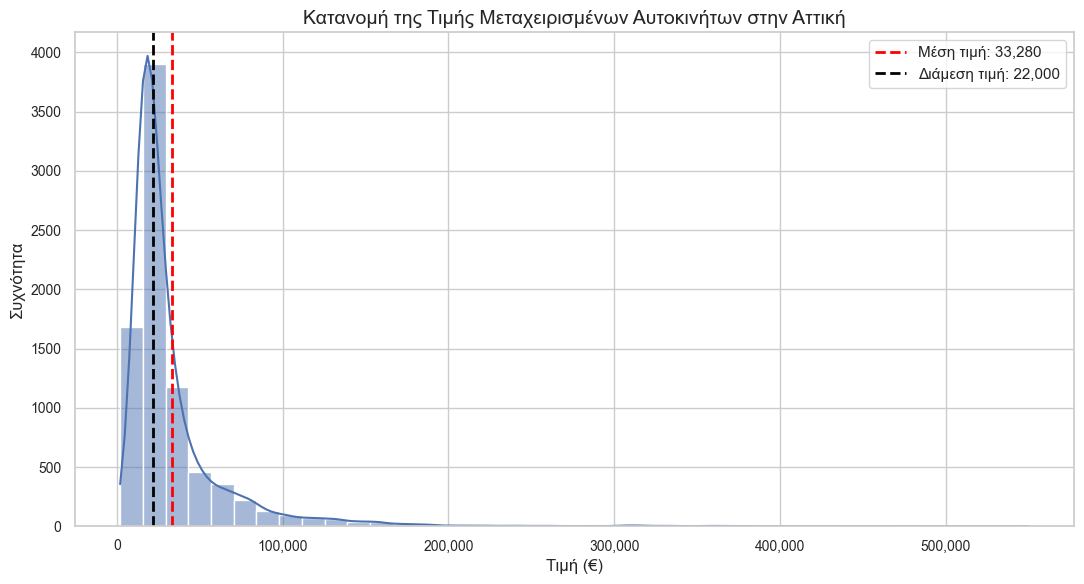

In [7]:
# ===============================
# Notebook 5 - Κατανομή της τιμής
# ===============================

from matplotlib.ticker import FuncFormatter

# Υπολογισμός βασικών σημείων αναφοράς
price_mean = analysis_df["price"].mean()
price_median = analysis_df["price"].median()

# Συνάρτηση μορφοποίησης άξονα x
def format_thousands(x, pos):
    return f"{int(x):,}"

# Δημιουργία γραφήματος
plt.figure(figsize=(11, 6))

sns.histplot(
    data=analysis_df,
    x="price",
    bins=40,
    kde=True
)

# Γραμμές μέσης και διάμεσης τιμής
plt.axvline(
    price_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Μέση τιμή: {price_mean:,.0f}"
)

plt.axvline(
    price_median,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Διάμεση τιμή: {price_median:,.0f}"
)

# Τίτλοι και labels
plt.title("Κατανομή της Τιμής Μεταχειρισμένων Αυτοκινήτων στην Αττική")
plt.xlabel("Τιμή (€)")
plt.ylabel("Συχνότητα")

# Μορφοποίηση άξονα x
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thousands))

# Legend
plt.legend()

# Αποθήκευση γραφήματος
save_plot("notebook5_price_distribution.png")

plt.show()

## Εστιασμένη Απεικόνιση της Κατανομής της Τιμής

Η αρχική απεικόνιση της τιμής επιβεβαιώνει ότι η αγορά παρουσιάζει έντονη δεξιά ασυμμετρία, με παρουσία περιορισμένου αριθμού πολύ υψηλών τιμών που εκτείνουν σημαντικά τη δεξιά ουρά της κατανομής.

Ωστόσο, η ύπαρξη αυτών των ακραίων τιμών καθιστά δυσκολότερη την οπτική ανάγνωση του κεντρικού τμήματος της αγοράς, δηλαδή του εύρους τιμών στο οποίο συγκεντρώνεται η μεγάλη πλειονότητα των παρατηρήσεων.

Για τον λόγο αυτό, ακολουθεί μία πιο εστιασμένη απεικόνιση της τιμής, με περιορισμό του άξονα σε ρεαλιστικότερο εύρος, ώστε να αναδειχθεί καθαρότερα η δομή του κύριου όγκου της αγοράς και να υποστηριχθεί καλύτερα η επόμενη διαδικασία δημιουργίας price segments.

95ο εκατοστημόριο τιμής: 92,850 €
Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_price_distribution_zoomed.png


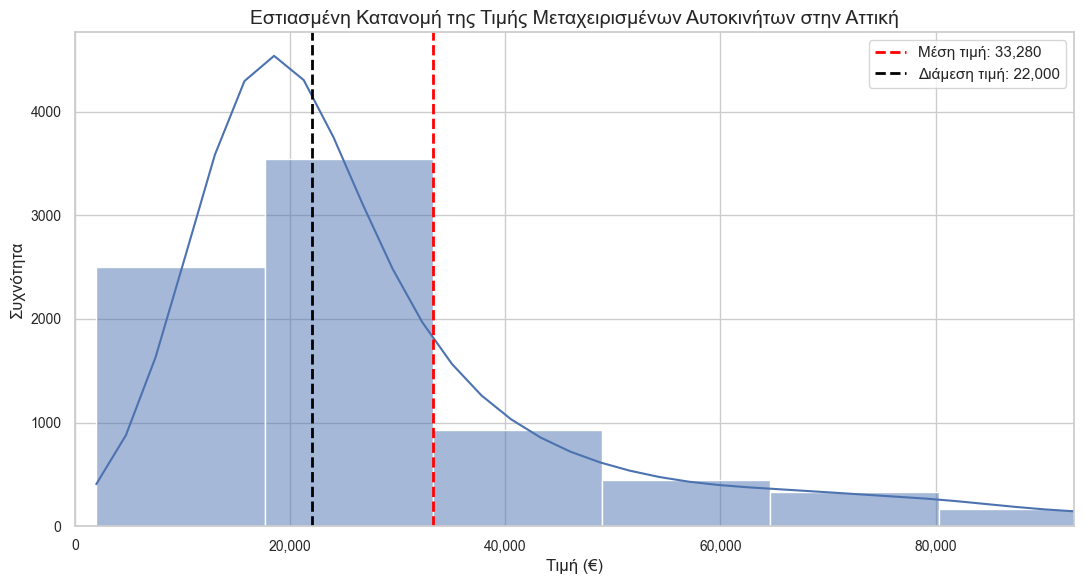

In [8]:
# ===============================
# Notebook 5 - Εστιασμένη απεικόνιση της τιμής
# ===============================

from matplotlib.ticker import FuncFormatter

# Υπολογισμός βασικών σημείων αναφοράς
price_mean = analysis_df["price"].mean()
price_median = analysis_df["price"].median()
price_q95 = analysis_df["price"].quantile(0.95)

print(f"95ο εκατοστημόριο τιμής: {price_q95:,.0f} €")

# Συνάρτηση μορφοποίησης άξονα x
def format_thousands(x, pos):
    return f"{int(x):,}"

# Δημιουργία zoomed γραφήματος
plt.figure(figsize=(11, 6))

sns.histplot(
    data=analysis_df,
    x="price",
    bins=35,
    kde=True
)

# Γραμμές μέσης και διάμεσης τιμής
plt.axvline(
    price_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Μέση τιμή: {price_mean:,.0f}"
)

plt.axvline(
    price_median,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Διάμεση τιμή: {price_median:,.0f}"
)

# Εστιασμός στον κύριο όγκο της αγοράς
plt.xlim(0, price_q95)

# Τίτλοι και labels
plt.title("Εστιασμένη Κατανομή της Τιμής Μεταχειρισμένων Αυτοκινήτων στην Αττική")
plt.xlabel("Τιμή (€)")
plt.ylabel("Συχνότητα")

# Μορφοποίηση άξονα x
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thousands))

# Legend
plt.legend()

# Αποθήκευση γραφήματος
save_plot("notebook5_price_distribution_zoomed.png")

plt.show()

## Ερμηνεία της Κατανομής της Τιμής

Η συνολική και η εστιασμένη απεικόνιση της τιμής επιβεβαιώνουν ότι η αγορά μεταχειρισμένων αυτοκινήτων στην Αττική χαρακτηρίζεται από **έντονη δεξιά ασυμμετρία**. Η μεγάλη πλειονότητα των παρατηρήσεων συγκεντρώνεται σε χαμηλότερα και μεσαία επίπεδα τιμών, ενώ ένα μικρότερο πλήθος οχημάτων εκτείνεται προς πολύ υψηλότερες τιμές, διαμορφώνοντας μακριά δεξιά ουρά.

Η απόσταση μεταξύ μέσης και διάμεσης τιμής ενισχύει την παραπάνω εικόνα, καθώς η μέση τιμή επηρεάζεται περισσότερο από τις ακριβότερες παρατηρήσεις και μετατοπίζεται προς τα πάνω. Αντίθετα, η διάμεση τιμή αποτυπώνει πιο πιστά το κεντρικό σημείο της αγοράς και φαίνεται να εκφράζει καλύτερα το «τυπικό» επίπεδο τιμής των μεταχειρισμένων οχημάτων του δείγματος.

Η εστιασμένη απεικόνιση δείχνει καθαρότερα ότι ο κύριος όγκος της αγοράς συγκεντρώνεται σε σαφώς περιορισμένο εύρος τιμών, ενώ οι πολύ υψηλές τιμές αποτελούν περισσότερο ειδικές ή premium περιπτώσεις παρά τον κανόνα της αγοράς.

Το εύρημα αυτό είναι ιδιαίτερα σημαντικό για τη συνέχεια της ανάλυσης, καθώς υποστηρίζει τη δημιουργία price segments και δείχνει ότι η αγορά δεν είναι ομοιογενής, αλλά διαρθρώνεται σε επιμέρους ζώνες τιμολόγησης με διαφορετικά χαρακτηριστικά.

## Boxplot της Τιμής και Οπτική Ανάδειξη Ακραίων Τιμών

Πέρα από την κατανομή της τιμής, είναι χρήσιμο να εξεταστεί και η θέση των ακραίων παρατηρήσεων με τρόπο πιο συμπυκνωμένο και άμεσα συγκρίσιμο.

Το boxplot της τιμής επιτρέπει την οπτική αποτύπωση:

- του κεντρικού εύρους της αγοράς,
- της διάμεσης τιμής,
- της διασποράς των παρατηρήσεων,
- και της παρουσίας ακραίων τιμών που εκτείνονται πέρα από το κύριο σώμα της κατανομής.

Η απεικόνιση αυτή λειτουργεί συμπληρωματικά προς τα προηγούμενα ιστογράμματα και ενισχύει τη μεθοδολογική βάση για τη δημιουργία price segments στην επόμενη ενότητα.

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_price_boxplot.png


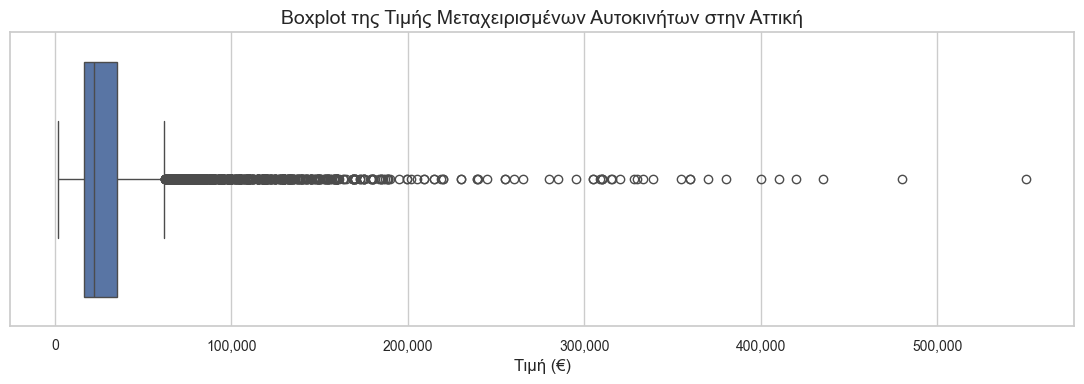

In [9]:
# ===============================
# Notebook 5 - Boxplot της τιμής
# ===============================

from matplotlib.ticker import FuncFormatter

# Συνάρτηση μορφοποίησης άξονα x
def format_thousands(x, pos):
    return f"{int(x):,}"

plt.figure(figsize=(11, 4))

sns.boxplot(
    x=analysis_df["price"],
    orient="h"
)

plt.title("Boxplot της Τιμής Μεταχειρισμένων Αυτοκινήτων στην Αττική")
plt.xlabel("Τιμή (€)")
plt.ylabel("")

# Μορφοποίηση άξονα x
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thousands))

# Αποθήκευση γραφήματος
save_plot("notebook5_price_boxplot.png")

plt.show()

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_price_boxplot_zoomed.png


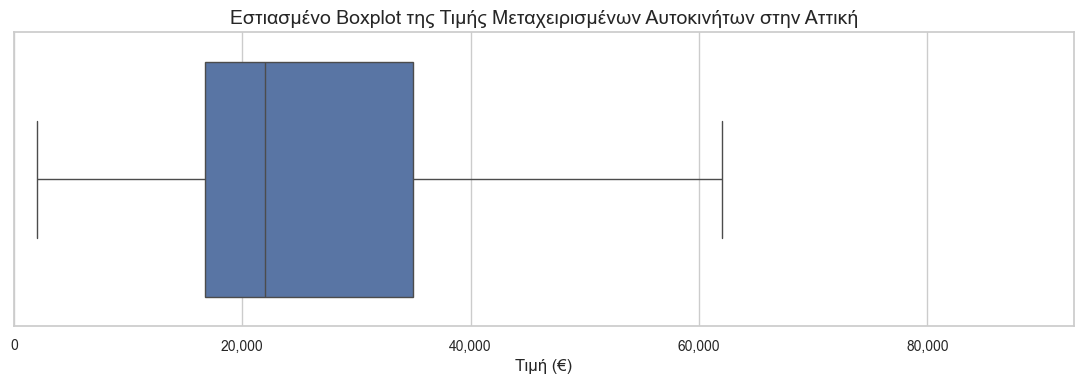

In [10]:
# ===============================
# Notebook 5 - Εστιασμένο boxplot της τιμής
# ===============================

from matplotlib.ticker import FuncFormatter

# 95ο εκατοστημόριο για εστιασμένη απεικόνιση
price_q95 = analysis_df["price"].quantile(0.95)

# Συνάρτηση μορφοποίησης άξονα x
def format_thousands(x, pos):
    return f"{int(x):,}"

plt.figure(figsize=(11, 4))

sns.boxplot(
    x=analysis_df["price"],
    orient="h",
    showfliers=False
)

# Εστίαση στον κύριο όγκο της αγοράς
plt.xlim(0, price_q95)

plt.title("Εστιασμένο Boxplot της Τιμής Μεταχειρισμένων Αυτοκινήτων στην Αττική")
plt.xlabel("Τιμή (€)")
plt.ylabel("")

# Μορφοποίηση άξονα x
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thousands))

# Αποθήκευση γραφήματος
save_plot("notebook5_price_boxplot_zoomed.png")

plt.show()

## Ερμηνεία του Boxplot της Τιμής

Το boxplot της τιμής επιβεβαιώνει ότι η αγορά μεταχειρισμένων αυτοκινήτων στην Αττική παρουσιάζει σημαντική ετερογένεια και έντονη παρουσία ακραίων τιμών προς τα δεξιά. Η πλήρης απεικόνιση δείχνει ότι, παρότι το κύριο σώμα της αγοράς συγκεντρώνεται σε πολύ χαμηλότερα επίπεδα τιμών, υπάρχει μεγάλος αριθμός παρατηρήσεων που εκτείνονται αρκετά πάνω από το κεντρικό εύρος.

Η εστιασμένη εκδοχή του boxplot επιτρέπει καθαρότερη ανάγνωση του βασικού τμήματος της αγοράς. Από αυτήν προκύπτει ότι το ενδοτεταρτημοριακό εύρος της τιμής βρίσκεται σε σχετικά περιορισμένη ζώνη, ενώ η διάμεση τιμή τοποθετείται πιο κοντά στο κάτω μέρος της συνολικής κλίμακας τιμών, γεγονός που είναι συμβατό με τη δεξιά ασυμμετρία που παρατηρήθηκε και στα ιστογράμματα.

Συνεπώς, η αγορά δεν εμφανίζει ομοιογενή τιμολογιακή δομή, αλλά οργανώνεται γύρω από έναν κεντρικό πυρήνα οχημάτων μεσαίας τιμής και από μια εκτεταμένη ουρά ακριβότερων περιπτώσεων. Το εύρημα αυτό ενισχύει τη λογική της επόμενης ενότητας, δηλαδή της δημιουργίας price segments για πιο συστηματική μελέτη των επιμέρους ζωνών της αγοράς.

## Δημιουργία Price Segments

Μετά την περιγραφική διερεύνηση της τιμής και την επιβεβαίωση ότι η αγορά παρουσιάζει έντονη ασυμμετρία και εσωτερική ετερογένεια, το επόμενο στάδιο της ανάλυσης αφορά τη δημιουργία διακριτών price segments.

Η τμηματοποίηση αυτή δεν αποσκοπεί στην επιβολή «φυσικών» ορίων στην αγορά, αλλά στη διαμόρφωση ενός αναλυτικού πλαισίου που θα επιτρέψει:

- τη σύγκριση διαφορετικών ζωνών τιμολόγησης,
- την περιγραφή του προφίλ των οχημάτων που ανήκουν σε κάθε κατηγορία,
- και την εξαγωγή πιο συστηματικών συμπερασμάτων για τη δομή της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική.

Για τους σκοπούς του παρόντος notebook, η κύρια στρατηγική τμηματοποίησης θα βασιστεί σε **quantile-based segmentation**, ώστε τα επιμέρους segments να είναι αναλυτικά ισορροπημένα και κατάλληλα για συγκριτική διερεύνηση.

Η προσέγγιση αυτή είναι ιδιαίτερα χρήσιμη σε αγορές με ασύμμετρη κατανομή τιμών, καθώς αποφεύγει τη δημιουργία υπερβολικά άνισων ομάδων και επιτρέπει πιο σταθερές συγκρίσεις μεταξύ χαμηλότερων, μεσαίων και υψηλότερων ζωνών τιμολόγησης.

In [11]:
# ===============================
# Notebook 5 - Δημιουργία price segments με qcut
# ===============================

# Σταθερές ετικέτες και σωστή σειρά των 4 price segments
segment_labels = [
    "Χαμηλή",
    "Χαμηλομεσαία",
    "Μεσοϋψηλή",
    "Υψηλή"
]

# Αν υπάρχει ήδη παλιά/σπασμένη έκδοση της στήλης, τη σβήνουμε
if "price_segment" in analysis_df.columns:
    analysis_df = analysis_df.drop(columns=["price_segment"])

# Δημιουργία 4 quantile-based segments
analysis_df["price_segment"] = pd.qcut(
    analysis_df["price"],
    q=4,
    labels=segment_labels
)

# Διασφάλιση σωστής σειράς κατηγοριών
analysis_df["price_segment"] = pd.Categorical(
    analysis_df["price_segment"],
    categories=segment_labels,
    ordered=True
)

# Γρήγορος έλεγχος ορθότητας
print("Κατηγορίες price_segment:")
print(list(analysis_df["price_segment"].cat.categories))
print("Missing τιμές στο price_segment:", int(analysis_df["price_segment"].isna().sum()))

# ---------------------------------
# 1. Πλήθος παρατηρήσεων ανά segment
# ---------------------------------

price_segment_counts = pd.DataFrame({
    "price_segment": segment_labels,
    "n_observations": [
        int((analysis_df["price_segment"] == seg).sum()) for seg in segment_labels
    ]
})

price_segment_counts["share_pct"] = (
    price_segment_counts["n_observations"] / len(analysis_df) * 100
).round(2)

print("\nΠλήθος παρατηρήσεων ανά price segment:")
display(price_segment_counts)

# Export
export_csv(price_segment_counts, "notebook5_price_segment_counts.csv")

# ---------------------------------
# 2. Όρια των segments με βάση τα quantiles
# ---------------------------------

price_cutoffs = (
    analysis_df["price"]
    .quantile([0.00, 0.25, 0.50, 0.75, 1.00])
    .reset_index()
)

price_cutoffs.columns = ["quantile", "price_value"]

print("\nΌρια τιμών των quantile-based segments:")
display(price_cutoffs)

# Export
export_csv(price_cutoffs, "notebook5_price_segment_cutoffs.csv")

# ---------------------------------
# 3. Πρώτη επισκόπηση του analysis_df με τα νέα segments
# ---------------------------------

print("\nΠρώτες γραμμές του dataset με τη νέα μεταβλητή price_segment:")
display(
    analysis_df[
        ["price", "price_segment", "make", "model", "fuel_type", "mileage", "age"]
    ].head()
)

Κατηγορίες price_segment:
['Χαμηλή', 'Χαμηλομεσαία', 'Μεσοϋψηλή', 'Υψηλή']
Missing τιμές στο price_segment: 0

Πλήθος παρατηρήσεων ανά price segment:


,price_segment,n_observations,share_pct
0,Χαμηλή,2077,25.04
1,Χαμηλομεσαία,2081,25.08
2,Μεσοϋψηλή,2069,24.94
3,Υψηλή,2069,24.94


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_price_segment_counts.csv

Όρια τιμών των quantile-based segments:


,quantile,price_value
0,0.00,"2,000.00"
1,0.25,"16,700.00"
2,0.50,"22,000.00"
3,0.75,"35,000.00"
4,1.00,"550,000.00"


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_price_segment_cutoffs.csv

Πρώτες γραμμές του dataset με τη νέα μεταβλητή price_segment:


,price,price_segment,make,model,fuel_type,mileage,age
0,"34,900.00",Μεσοϋψηλή,Audi,Q3,Βενζίνη,"10,500.00",1.00
1,"25,990.00",Μεσοϋψηλή,Toyota,Yaris Cross,Υβριδικό Βενζίνης,"10,018.00",1.00
2,"26,500.00",Μεσοϋψηλή,Peugeot,2008,Υβριδικό Βενζίνης,"3,000.00",1.00
3,"26,500.00",Μεσοϋψηλή,Peugeot,2008,Υβριδικό Βενζίνης,"2,900.00",1.00
6,"34,900.00",Μεσοϋψηλή,Opel,Grandland (X),Υβριδικό Βενζίνης,"6,900.00",1.00


## Ερμηνεία της Τμηματοποίησης της Τιμής

Η quantile-based τμηματοποίηση παρήγαγε τέσσερα price segments με σχεδόν ίσο πλήθος παρατηρήσεων και χωρίς ελλείπουσες τιμές στη νέα μεταβλητή `price_segment`. Το αποτέλεσμα αυτό επιβεβαιώνει ότι η συγκεκριμένη στρατηγική είναι κατάλληλη για συγκριτική ανάλυση της αγοράς.

Τα όρια που προέκυψαν από την κατανομή της τιμής δείχνουν ότι η αγορά μπορεί να διαχωριστεί στις ακόλουθες βασικές ζώνες:

- **Χαμηλή τιμή**: έως 16.700 €
- **Χαμηλομεσαία τιμή**: από 16.700 € έως 22.000 €
- **Μεσοϋψηλή τιμή**: από 22.000 € έως 35.000 €
- **Υψηλή τιμή**: άνω των 35.000 €

Η διάρθρωση αυτή είναι αναλυτικά χρήσιμη, διότι επιτρέπει τη μελέτη της αγοράς όχι ως ενός ενιαίου συνόλου, αλλά ως ενός συστήματος επιμέρους ζωνών τιμολόγησης με πιθανώς διαφορετικά χαρακτηριστικά ως προς την ηλικία, τα χιλιόμετρα, τα τεχνικά γνωρίσματα και τη σύνθεση των αγγελιών.

Επομένως, τα price segments μπορούν να χρησιμοποιηθούν ως βασικός άξονας της επόμενης φάσης της ανάλυσης, δηλαδή της περιγραφής και σύγκρισης του προφίλ κάθε υποαγοράς.

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_price_segment_counts.png


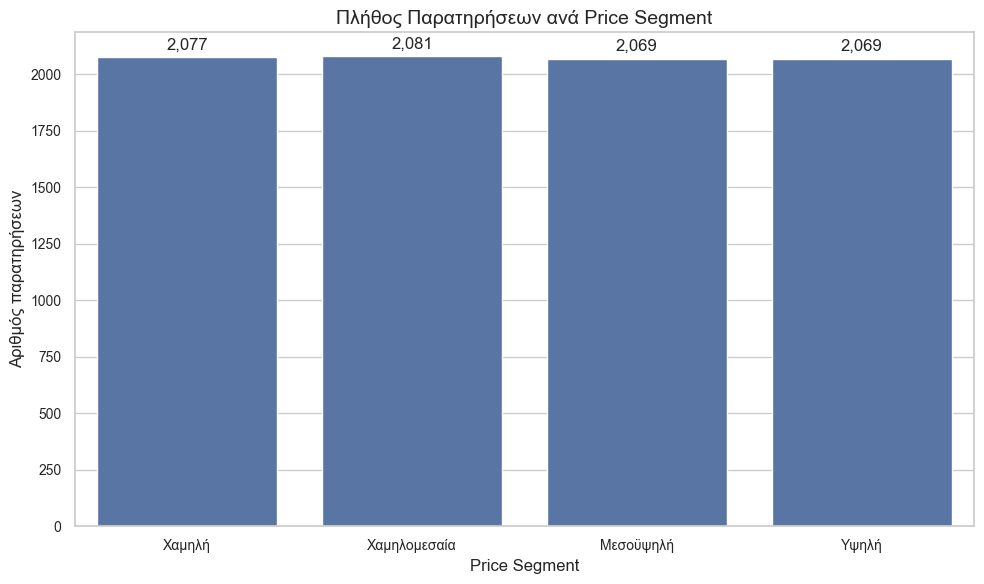

In [12]:
# ===============================
# Notebook 5 - Πλήθος παρατηρήσεων ανά price segment
# ===============================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=price_segment_counts,
    x="price_segment",
    y="n_observations"
)

plt.title("Πλήθος Παρατηρήσεων ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Αριθμός παρατηρήσεων")

# Προσθήκη labels πάνω από τις μπάρες
for i, value in enumerate(price_segment_counts["n_observations"]):
    plt.text(i, value + 20, f"{value:,}", ha="center", va="bottom")

# Αποθήκευση γραφήματος
save_plot("notebook5_price_segment_counts.png")

plt.show()

## Προφίλ των Price Segments

Αφού ορίστηκαν και αποτυπώθηκαν τα price segments, το επόμενο βήμα είναι η περιγραφή του προφίλ κάθε επιμέρους ζώνης τιμολόγησης.

Στόχος της ενότητας αυτής είναι να διερευνηθεί αν τα segments διαφοροποιούνται ουσιαστικά μεταξύ τους ως προς βασικά χαρακτηριστικά των οχημάτων και όχι μόνο ως προς το επίπεδο της τιμής.

Ειδικότερα, θα εξεταστούν συγκριτικά ανά segment:

- η διάμεση και μέση τιμή,
- τα χιλιόμετρα,
- η ηλικία,
- η ιπποδύναμη,
- ο κυβισμός,
- και, σε επόμενο στάδιο, η σύνθεση κατηγορικών μεταβλητών όπως το καύσιμο, η μετάδοση και ο κατασκευαστής.

Η ανάλυση αυτή είναι κρίσιμη, διότι επιτρέπει να διαπιστωθεί αν τα price segments αντιστοιχούν σε πραγματικά διακριτές υποαγορές με διαφορετικό τεχνικό και εμπορικό προφίλ.

In [13]:
# ===============================
# Notebook 5 - Summary table προφίλ ανά price segment
# ===============================

# Δημιουργία συνοπτικού πίνακα προφίλ ανά segment
segment_profile_summary = (
    analysis_df
    .groupby("price_segment", observed=False)
    .agg(
        n_observations=("price", "size"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_mileage=("mileage", "median"),
        mean_mileage=("mileage", "mean"),
        median_age=("age", "median"),
        mean_age=("age", "mean"),
        median_horsepower=("horsepower", "median"),
        mean_horsepower=("horsepower", "mean"),
        median_engine_size=("engine_size", "median"),
        mean_engine_size=("engine_size", "mean")
    )
    .reset_index()
)

# Στρογγυλοποίηση για καθαρότερη παρουσίαση
numeric_cols = segment_profile_summary.select_dtypes(include=[np.number]).columns.tolist()
segment_profile_summary[numeric_cols] = segment_profile_summary[numeric_cols].round(2)

print("Συνοπτικό προφίλ των price segments:")
display(segment_profile_summary)

# Export για reproducibility
export_csv(segment_profile_summary, "notebook5_segment_profile_summary.csv")

Συνοπτικό προφίλ των price segments:


,price_segment,n_observations,median_price,mean_price,median_mileage,mean_mileage,median_age,mean_age,median_horsepower,mean_horsepower,median_engine_size,mean_engine_size
0,Χαμηλή,2077,"13,750.00","13,345.93","67,245.00","70,253.86",5.00,4.21,100.00,94.60,"1,200.00","1,227.98"
1,Χαμηλομεσαία,2081,"18,990.00","19,127.83","50,900.00","54,669.70",4.00,3.66,120.00,122.65,"1,300.00","1,333.01"
2,Μεσοϋψηλή,2069,"27,300.00","27,571.90","48,384.00","53,639.46",4.00,3.73,155.00,179.65,"1,500.00","1,519.62"
3,Υψηλή,2069,"58,000.00","73,234.27","35,500.00","44,838.38",4.00,3.43,306.00,326.37,"2,000.00","2,266.44"


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_segment_profile_summary.csv


## Ερμηνεία του Προφίλ των Price Segments

Το συνοπτικό προφίλ των price segments δείχνει ότι η τμηματοποίηση δεν διαφοροποιεί απλώς τα οχήματα ως προς την τιμή, αλλά αποτυπώνει ευρύτερες διαφορές στο τεχνικό και εμπορικό τους προφίλ.

Παρατηρείται σαφής κλιμάκωση της διάμεσης και της μέσης τιμής από το χαμηλότερο προς το υψηλότερο segment, γεγονός που επιβεβαιώνει την εσωτερική συνοχή της τμηματοποίησης. Παράλληλα, τα χαμηλότερα segments συνδέονται με υψηλότερα χιλιόμετρα και μεγαλύτερη ηλικία, ενώ τα υψηλότερα segments χαρακτηρίζονται από χαμηλότερη χρήση και σχετικά νεότερο στόλο.

Ιδιαίτερα έντονη είναι η διαφοροποίηση στα τεχνικά χαρακτηριστικά. Όσο αυξάνεται το επίπεδο του segment, αυξάνονται συστηματικά τόσο η ιπποδύναμη όσο και ο κυβισμός, γεγονός που δείχνει ότι η ανώτερη ζώνη της αγοράς δεν αντανακλά μόνο υψηλότερη τιμολόγηση, αλλά και ουσιαστικά ισχυρότερα και πιθανώς πιο premium οχήματα.

Συνεπώς, τα price segments μπορούν να θεωρηθούν ως αναλυτικά χρήσιμες υποαγορές με διακριτό προφίλ. Το αποτέλεσμα αυτό δικαιολογεί την επόμενη φάση της ανάλυσης, δηλαδή τη γραφική σύγκριση των βασικών χαρακτηριστικών ανά segment.

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_median_price_by_segment.png


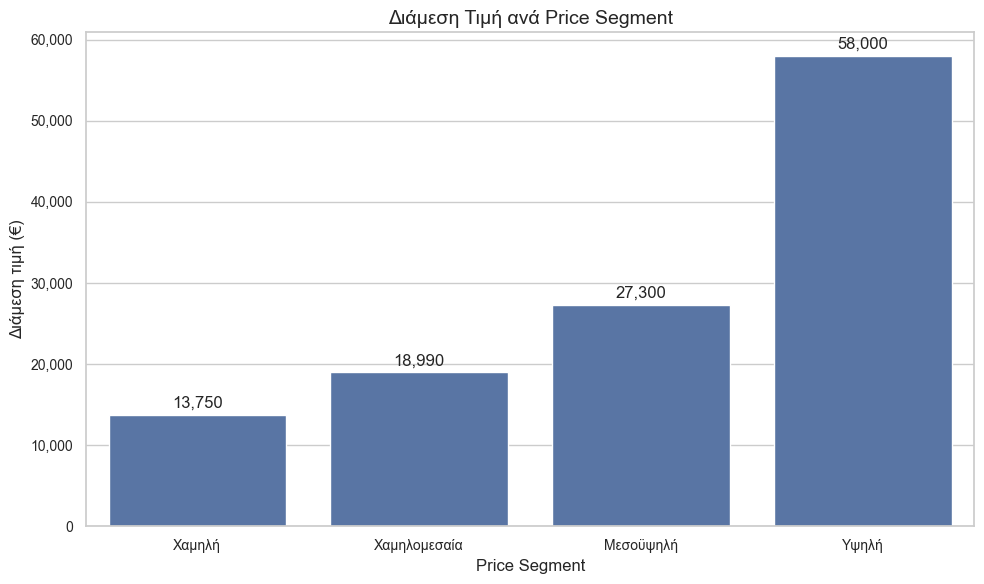

In [14]:
# ===============================
# Notebook 5 - Διάμεση τιμή ανά price segment
# ===============================

from matplotlib.ticker import FuncFormatter

# Συνάρτηση μορφοποίησης άξονα y
def format_thousands(x, pos):
    return f"{int(x):,}"

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile_summary,
    x="price_segment",
    y="median_price"
)

plt.title("Διάμεση Τιμή ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Διάμεση τιμή (€)")

# Μορφοποίηση άξονα y
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Labels πάνω από τις μπάρες
for i, value in enumerate(segment_profile_summary["median_price"]):
    plt.text(i, value + 500, f"{value:,.0f}", ha="center", va="bottom")

# Αποθήκευση γραφήματος
save_plot("notebook5_median_price_by_segment.png")

plt.show()

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_median_mileage_by_segment.png


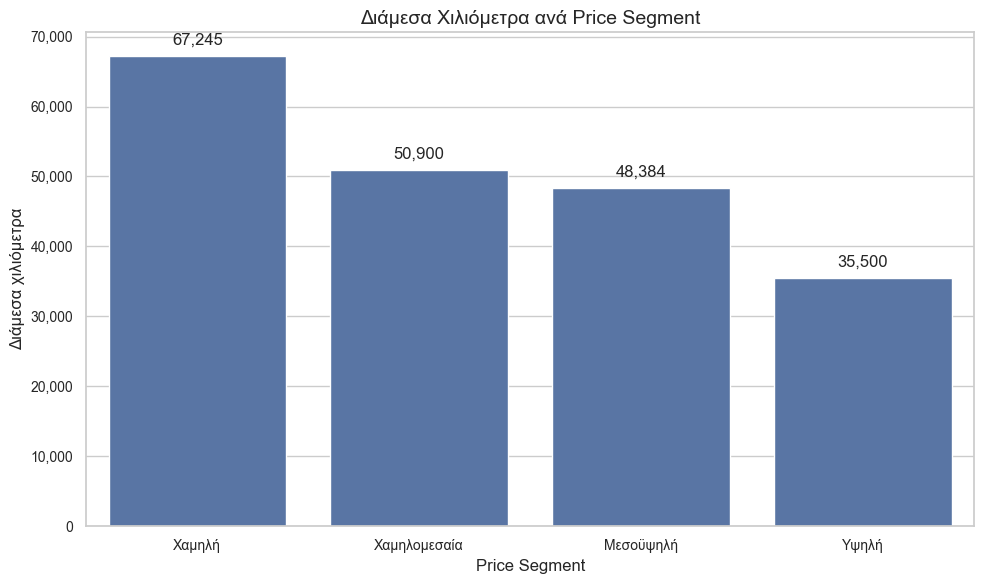

In [15]:
# ===============================
# Notebook 5 - Διάμεσα χιλιόμετρα ανά price segment
# ===============================

from matplotlib.ticker import FuncFormatter

# Συνάρτηση μορφοποίησης άξονα y
def format_thousands(x, pos):
    return f"{int(x):,}"

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile_summary,
    x="price_segment",
    y="median_mileage"
)

plt.title("Διάμεσα Χιλιόμετρα ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Διάμεσα χιλιόμετρα")

# Μορφοποίηση άξονα y
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Labels πάνω από τις μπάρες
for i, value in enumerate(segment_profile_summary["median_mileage"]):
    plt.text(i, value + 1200, f"{value:,.0f}", ha="center", va="bottom")

# Αποθήκευση γραφήματος
save_plot("notebook5_median_mileage_by_segment.png")

plt.show()

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_median_age_by_segment.png


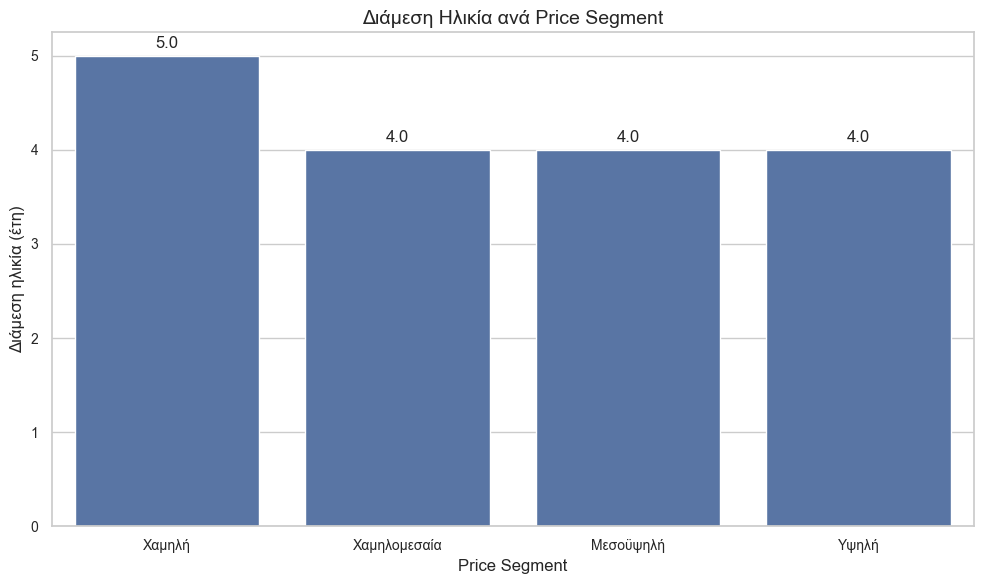

In [16]:
# ===============================
# Notebook 5 - Διάμεση ηλικία ανά price segment
# ===============================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile_summary,
    x="price_segment",
    y="median_age"
)

plt.title("Διάμεση Ηλικία ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Διάμεση ηλικία (έτη)")

# Labels πάνω από τις μπάρες
for i, value in enumerate(segment_profile_summary["median_age"]):
    plt.text(i, value + 0.05, f"{value:.1f}", ha="center", va="bottom")

# Αποθήκευση γραφήματος
save_plot("notebook5_median_age_by_segment.png")

plt.show()

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_median_horsepower_by_segment.png


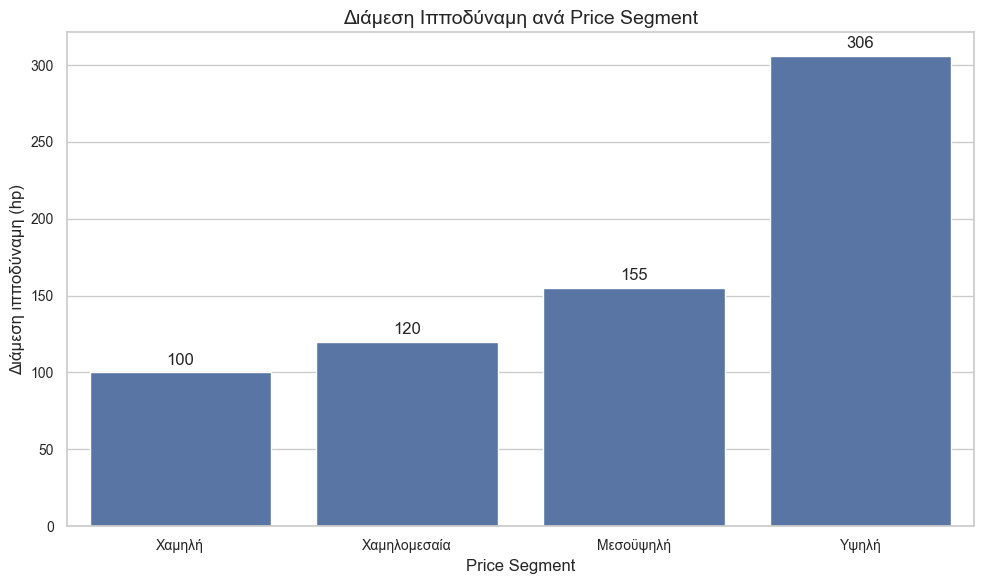

In [17]:
# ===============================
# Notebook 5 - Διάμεση ιπποδύναμη ανά price segment
# ===============================

from matplotlib.ticker import FuncFormatter

# Συνάρτηση μορφοποίησης άξονα y
def format_thousands(x, pos):
    return f"{int(x):,}"

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile_summary,
    x="price_segment",
    y="median_horsepower"
)

plt.title("Διάμεση Ιπποδύναμη ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Διάμεση ιπποδύναμη (hp)")

# Labels πάνω από τις μπάρες
for i, value in enumerate(segment_profile_summary["median_horsepower"]):
    plt.text(i, value + 3, f"{value:,.0f}", ha="center", va="bottom")

# Αποθήκευση γραφήματος
save_plot("notebook5_median_horsepower_by_segment.png")

plt.show()

Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_median_engine_size_by_segment.png


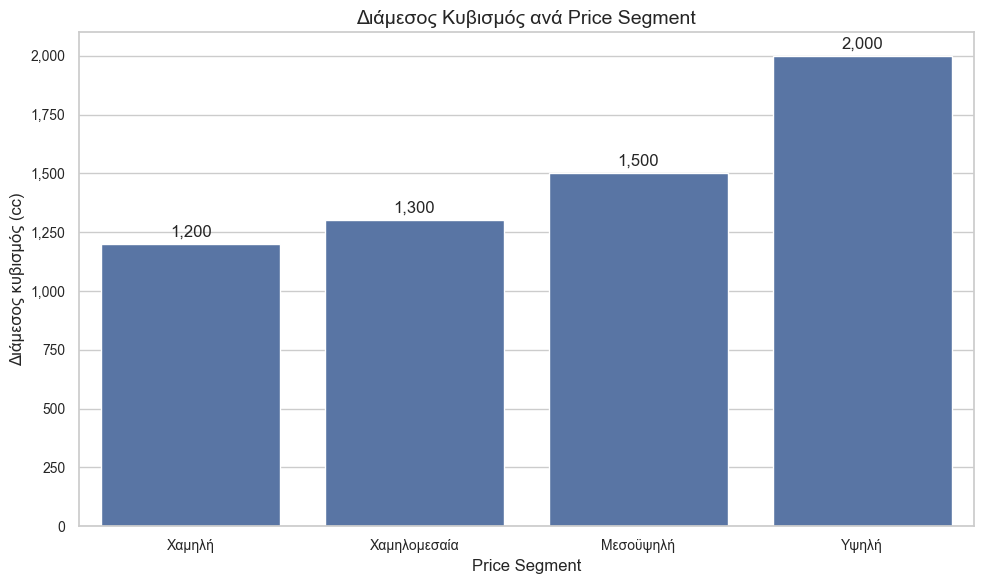

In [18]:
# ===============================
# Notebook 5 - Διάμεσος κυβισμός ανά price segment
# ===============================

from matplotlib.ticker import FuncFormatter

# Συνάρτηση μορφοποίησης άξονα y
def format_thousands(x, pos):
    return f"{int(x):,}"

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_profile_summary,
    x="price_segment",
    y="median_engine_size"
)

plt.title("Διάμεσος Κυβισμός ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Διάμεσος κυβισμός (cc)")

# Μορφοποίηση άξονα y
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Labels πάνω από τις μπάρες
for i, value in enumerate(segment_profile_summary["median_engine_size"]):
    plt.text(i, value + 20, f"{value:,.0f}", ha="center", va="bottom")

# Αποθήκευση γραφήματος
save_plot("notebook5_median_engine_size_by_segment.png")

plt.show()

## Ερμηνεία των Βασικών Χαρακτηριστικών ανά Price Segment

Η σύγκριση των βασικών αριθμητικών χαρακτηριστικών ανά price segment δείχνει ότι η τμηματοποίηση αποτυπώνει ουσιαστικά διαφορετικές υποαγορές και όχι απλώς τεχνητές κατηγορίες τιμής.

Πρώτον, παρατηρείται σαφής αρνητική σχέση μεταξύ τιμής και χιλιομέτρων. Τα χαμηλότερα segments συνδέονται με υψηλότερη διάμεση χρήση, ενώ τα ακριβότερα segments εμφανίζουν αισθητά χαμηλότερα χιλιόμετρα. Το εύρημα αυτό είναι συνεπές με τη βασική λογική της αγοράς μεταχειρισμένων οχημάτων, όπου η μικρότερη χρήση συνδέεται με υψηλότερη αποτίμηση.

Δεύτερον, η ηλικία διαφοροποιείται λιγότερο έντονα σε σχέση με τις υπόλοιπες μεταβλητές. Αν και το χαμηλότερο segment εμφανίζεται ελαφρώς παλαιότερο, τα υπόλοιπα segments συγκεντρώνονται σε σχετικά κοντινά επίπεδα διάμεσης ηλικίας. Αυτό υποδηλώνει ότι, στο παρόν δείγμα, η ηλικία από μόνη της δεν αρκεί για να εξηγήσει πλήρως τις διαφορές τιμής μεταξύ των επιμέρους υποαγορών.

Τρίτον, οι τεχνικές μεταβλητές διαφοροποιούνται πολύ πιο έντονα. Η διάμεση ιπποδύναμη και ο διάμεσος κυβισμός αυξάνονται συστηματικά από το χαμηλό προς το υψηλό segment, γεγονός που δείχνει ότι οι ακριβότερες υποαγορές αντιστοιχούν σε ισχυρότερα, μεγαλύτερου κυβισμού και πιθανώς ποιοτικά ανώτερα ή πιο premium οχήματα.

Συνολικά, τα price segments φαίνεται να οργανώνονται γύρω από έναν σαφή μηχανισμό διαφοροποίησης: τα φθηνότερα οχήματα είναι συνήθως περισσότερο χρησιμοποιημένα και τεχνικά πιο περιορισμένα, ενώ τα ακριβότερα οχήματα συνδέονται με χαμηλότερη χρήση και αισθητά ισχυρότερα τεχνικά χαρακτηριστικά. Η παρατήρηση αυτή ενισχύει την ερμηνευτική αξία της τμηματοποίησης και δημιουργεί τη βάση για την επόμενη φάση της ανάλυσης, δηλαδή τη σύγκριση κατηγορικών χαρακτηριστικών ανά segment.

## Σύνθεση Κατηγορικών Χαρακτηριστικών ανά Price Segment

Αφού εξετάστηκαν τα βασικά αριθμητικά χαρακτηριστικά των price segments, το επόμενο στάδιο αφορά τη μελέτη της κατηγορικής σύνθεσης κάθε υποαγοράς.

Η ενότητα αυτή είναι σημαντική, διότι επιτρέπει να διερευνηθεί αν οι ζώνες τιμολόγησης διαφοροποιούνται και ως προς το είδος των οχημάτων που τις συγκροτούν, πέρα από τις διαφορές στην τιμή, στα χιλιόμετρα και στα τεχνικά χαρακτηριστικά.

Συγκεκριμένα, θα εξεταστούν συγκριτικά ανά segment κατηγορικές μεταβλητές όπως:

- το καύσιμο,
- η μετάδοση,
- ο κατασκευαστής,
- και, σε επόμενο στάδιο, η γεωγραφική κατανομή των αγγελιών.

Η ανάλυση αυτή συμπληρώνει το προφίλ των price segments και βοηθά στην εξαγωγή πιο ολοκληρωμένων market-level συμπερασμάτων για τη δομή της αγοράς μεταχειρισμένων αυτοκινήτων στην Αττική.

Πλήθος αγγελιών ανά fuel_type και price_segment:


fuel_type,Βενζίνη,Πετρέλαιο,Υβριδικό Βενζίνης,Plug-in Hybrid Βενζίνης,Ηλεκτρικό,Υβριδικό Πετρελαίου,Plug-in Hybrid Πετρελαίου,LPG / Βενζίνη,CNG / Βενζίνη
price_segment,,,,,,,,,
Χαμηλή,1084,568,275,6,90,3,0,32,19
Χαμηλομεσαία,963,406,494,58,100,14,0,31,15
Μεσοϋψηλή,552,323,481,497,178,27,2,3,6
Υψηλή,357,256,176,611,284,226,159,0,0


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_fuel_type_by_segment_counts.csv

Ποσοστιαία σύνθεση fuel_type μέσα σε κάθε price segment:


fuel_type,Βενζίνη,Πετρέλαιο,Υβριδικό Βενζίνης,Plug-in Hybrid Βενζίνης,Ηλεκτρικό,Υβριδικό Πετρελαίου,Plug-in Hybrid Πετρελαίου,LPG / Βενζίνη,CNG / Βενζίνη
price_segment,,,,,,,,,
Χαμηλή,52.19,27.35,13.24,0.29,4.33,0.14,0.00,1.54,0.91
Χαμηλομεσαία,46.28,19.51,23.74,2.79,4.81,0.67,0.00,1.49,0.72
Μεσοϋψηλή,26.68,15.61,23.25,24.02,8.60,1.30,0.10,0.14,0.29
Υψηλή,17.25,12.37,8.51,29.53,13.73,10.92,7.68,0.00,0.00


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_fuel_type_by_segment_shares.csv
Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_fuel_type_by_segment_stacked.png


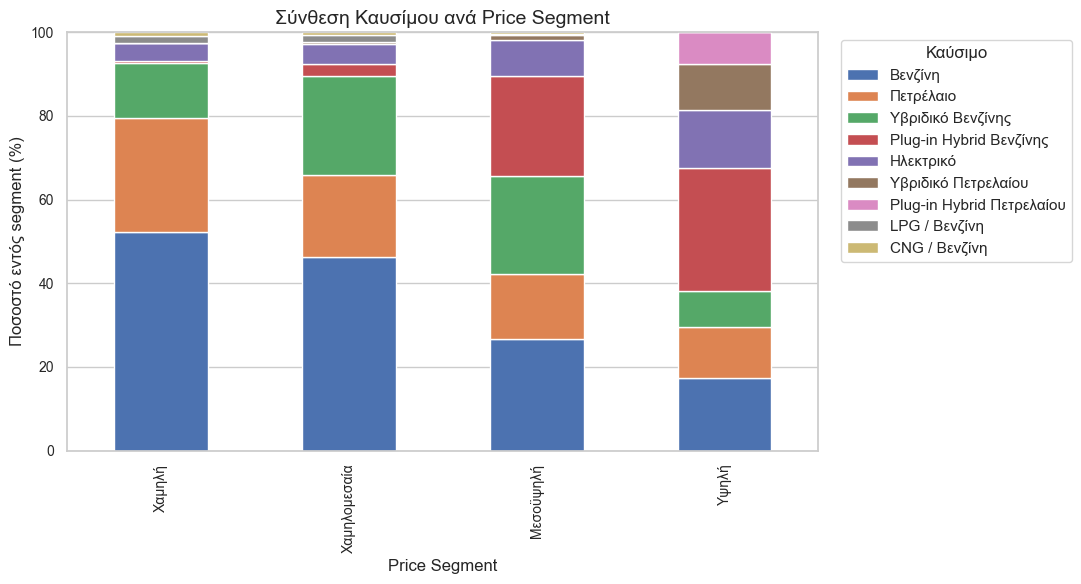

In [19]:
# ===============================
# Notebook 5 - Σύνθεση καυσίμου ανά price segment
# ===============================

# ---------------------------------
# 1. Πίνακας counts
# ---------------------------------

fuel_counts = pd.crosstab(
    analysis_df["price_segment"],
    analysis_df["fuel_type"]
)

# Ταξινόμηση στηλών με βάση τη συνολική συχνότητα
fuel_counts = fuel_counts.loc[:, fuel_counts.sum().sort_values(ascending=False).index]

print("Πλήθος αγγελιών ανά fuel_type και price_segment:")
display(fuel_counts)

export_csv(
    fuel_counts.reset_index(),
    "notebook5_fuel_type_by_segment_counts.csv"
)

# ---------------------------------
# 2. Πίνακας ποσοστών ανά segment
# ---------------------------------

fuel_shares = pd.crosstab(
    analysis_df["price_segment"],
    analysis_df["fuel_type"],
    normalize="index"
) * 100

fuel_shares = fuel_shares.loc[:, fuel_counts.columns].round(2)

print("\nΠοσοστιαία σύνθεση fuel_type μέσα σε κάθε price segment:")
display(fuel_shares)

export_csv(
    fuel_shares.reset_index(),
    "notebook5_fuel_type_by_segment_shares.csv"
)

# ---------------------------------
# 3. 100% stacked bar chart
# ---------------------------------

ax = fuel_shares.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Σύνθεση Καυσίμου ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Ποσοστό εντός segment (%)")
plt.legend(title="Καύσιμο", bbox_to_anchor=(1.02, 1), loc="upper left")

# Labels άξονα y σε ποσοστά
plt.ylim(0, 100)

# Αποθήκευση γραφήματος
save_plot("notebook5_fuel_type_by_segment_stacked.png")

plt.show()

## Ερμηνεία της Σύνθεσης Καυσίμου ανά Price Segment

Η σύγκριση της σύνθεσης καυσίμου ανά price segment δείχνει ότι οι υποαγορές διαφοροποιούνται όχι μόνο ως προς την τιμή και τα τεχνικά χαρακτηριστικά, αλλά και ως προς την τεχνολογική τους σύνθεση.

Στα χαμηλότερα segments κυριαρχούν οι πιο συμβατικές επιλογές καυσίμου, κυρίως η βενζίνη και σε δεύτερο βαθμό το πετρέλαιο. Η εικόνα αυτή είναι συμβατή με το γεγονός ότι οι οικονομικότερες υποαγορές περιλαμβάνουν σε μεγαλύτερο βαθμό παλαιότερα ή πιο συμβατικά οχήματα.

Αντίθετα, όσο αυξάνεται το επίπεδο του segment, μειώνεται αισθητά η συμμετοχή της απλής βενζίνης και του πετρελαίου, ενώ ενισχύεται η παρουσία εξηλεκτρισμένων μορφών κίνησης, όπως τα υβριδικά βενζίνης, τα plug-in hybrid βενζίνης και τα ηλεκτρικά οχήματα. Η τάση αυτή γίνεται ιδιαίτερα εμφανής στα δύο υψηλότερα segments.

Στο υψηλότερο segment, η συμμετοχή των plug-in hybrid και των ηλεκτρικών οχημάτων είναι σαφώς αυξημένη, γεγονός που υποδηλώνει ότι η ανώτερη ζώνη της αγοράς συνδέεται περισσότερο με νεότερες τεχνολογίες κίνησης και πιθανώς με πιο premium κατηγορίες οχημάτων.

Συνεπώς, η σύνθεση καυσίμου επιβεβαιώνει ότι τα price segments αντιστοιχούν σε ουσιαστικά διαφορετικές υποαγορές. Η διαφοροποίηση της αγοράς δεν αφορά μόνο το επίπεδο της τιμής, αλλά και τον τεχνολογικό χαρακτήρα των οχημάτων που περιλαμβάνει κάθε ζώνη τιμολόγησης.

Πλήθος αγγελιών ανά transmission και price_segment:


transmission,Αυτόματο,Χειροκίνητο,Ημιαυτόματο
price_segment,,,
Χαμηλή,371,1705,1
Χαμηλομεσαία,1058,1022,1
Μεσοϋψηλή,1797,264,8
Υψηλή,2031,30,8


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_transmission_by_segment_counts.csv

Ποσοστιαία σύνθεση transmission μέσα σε κάθε price segment:


transmission,Αυτόματο,Χειροκίνητο,Ημιαυτόματο
price_segment,,,
Χαμηλή,17.86,82.09,0.05
Χαμηλομεσαία,50.84,49.11,0.05
Μεσοϋψηλή,86.85,12.76,0.39
Υψηλή,98.16,1.45,0.39


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_transmission_by_segment_shares.csv
Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_transmission_by_segment_stacked.png


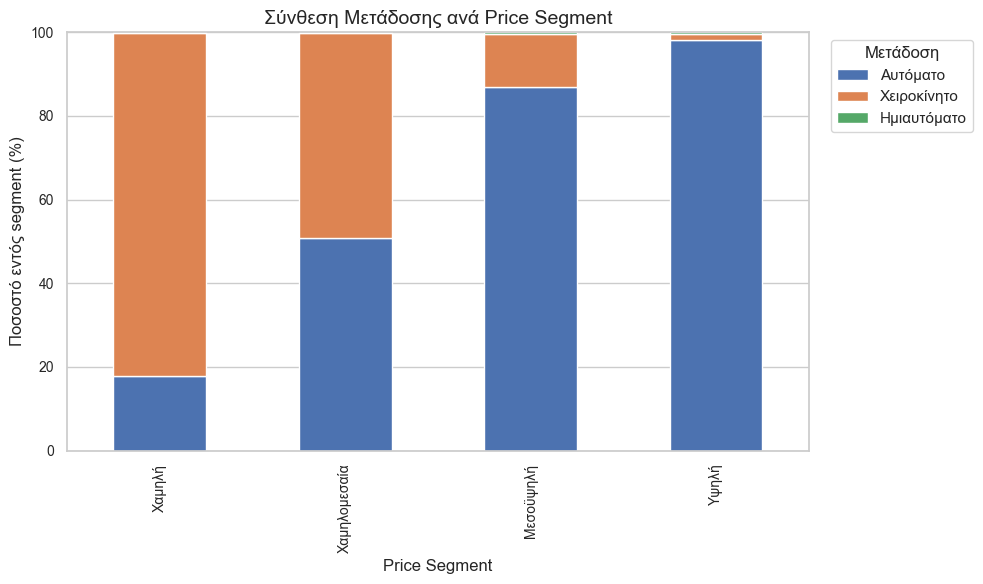

In [20]:
# ===============================
# Notebook 5 - Σύνθεση μετάδοσης ανά price segment
# ===============================

# ---------------------------------
# 1. Πίνακας counts
# ---------------------------------

transmission_counts = pd.crosstab(
    analysis_df["price_segment"],
    analysis_df["transmission"]
)

transmission_counts = transmission_counts.loc[:, transmission_counts.sum().sort_values(ascending=False).index]

print("Πλήθος αγγελιών ανά transmission και price_segment:")
display(transmission_counts)

export_csv(
    transmission_counts.reset_index(),
    "notebook5_transmission_by_segment_counts.csv"
)

# ---------------------------------
# 2. Πίνακας ποσοστών ανά segment
# ---------------------------------

transmission_shares = pd.crosstab(
    analysis_df["price_segment"],
    analysis_df["transmission"],
    normalize="index"
) * 100

transmission_shares = transmission_shares.loc[:, transmission_counts.columns].round(2)

print("\nΠοσοστιαία σύνθεση transmission μέσα σε κάθε price segment:")
display(transmission_shares)

export_csv(
    transmission_shares.reset_index(),
    "notebook5_transmission_by_segment_shares.csv"
)

# ---------------------------------
# 3. 100% stacked bar chart
# ---------------------------------

ax = transmission_shares.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Σύνθεση Μετάδοσης ανά Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Ποσοστό εντός segment (%)")
plt.legend(title="Μετάδοση", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, 100)

save_plot("notebook5_transmission_by_segment_stacked.png")

plt.show()

## Ερμηνεία της Σύνθεσης Μετάδοσης ανά Price Segment

Η σύγκριση της μετάδοσης ανά price segment δείχνει πολύ έντονη διαφοροποίηση μεταξύ των επιμέρους υποαγορών.

Στο χαμηλότερο segment κυριαρχεί καθαρά το χειροκίνητο κιβώτιο, γεγονός που είναι συμβατό με το πιο οικονομικό και συμβατικό προφίλ των οχημάτων αυτής της κατηγορίας. Στο χαμηλομεσαίο segment παρατηρείται ήδη σημαντική ενίσχυση της παρουσίας των αυτόματων οχημάτων, με αποτέλεσμα η σύνθεση να γίνεται περισσότερο ισορροπημένη.

Στα δύο υψηλότερα segments η εικόνα αλλάζει ριζικά. Η αυτόματη μετάδοση καθίσταται η κυρίαρχη μορφή, ενώ στο υψηλότερο segment σχεδόν το σύνολο των οχημάτων είναι αυτόματο. Η μεταβολή αυτή δείχνει ότι η ανώτερη ζώνη της αγοράς συνδέεται όχι μόνο με υψηλότερη τιμή και ισχυρότερα τεχνικά χαρακτηριστικά, αλλά και με διαφορετικές προτιμήσεις εξοπλισμού και τεχνολογικού επιπέδου.

Συνεπώς, η μετάδοση αποτελεί ακόμη έναν παράγοντα που επιβεβαιώνει ότι τα price segments αντιστοιχούν σε ουσιαστικά διαφορετικές υποαγορές. Η μετάβαση από το χειροκίνητο στο αυτόματο κιβώτιο είναι ιδιαίτερα σαφής όσο αυξάνεται το επίπεδο τιμής.

## Κατασκευαστής ανά Price Segment

Μετά τη σύγκριση του καυσίμου και της μετάδοσης, ακολουθεί η εξέταση της σύνθεσης των price segments ως προς τον κατασκευαστή.

Η μεταβλητή του κατασκευαστή είναι ιδιαίτερα σημαντική, διότι συνδέεται άμεσα με τη θέση κάθε οχήματος στην αγορά, το επίπεδο εξοπλισμού, το τεχνολογικό προφίλ και, σε πολλές περιπτώσεις, με το brand positioning του μοντέλου.

Δεδομένου ότι στο δείγμα περιλαμβάνεται μεγάλος αριθμός διαφορετικών κατασκευαστών, η ανάλυση θα επικεντρωθεί στους κυριότερους κατασκευαστές του δείγματος, ώστε η σύγκριση να παραμείνει αναγνώσιμη και ερμηνεύσιμη.

Στόχος είναι να διερευνηθεί αν ορισμένες μάρκες συγκεντρώνονται περισσότερο στα χαμηλότερα segments, ενώ άλλες εμφανίζουν εντονότερη παρουσία στις ανώτερες ζώνες τιμολόγησης.

Top 10 κατασκευαστές του analytical sample:
['Mercedes-Benz', 'Peugeot', 'BMW', 'Toyota', 'Opel', 'Volkswagen', 'Citroen', 'Ford', 'Audi', 'Hyundai']

Πλήθος αγγελιών ανά top-10 κατασκευαστή και price_segment:


make,Mercedes-Benz,Peugeot,Opel,Citroen,BMW,Toyota,Volkswagen,Ford,Hyundai,Audi
price_segment,,,,,,,,,,
Χαμηλή,6.00,262.00,326.00,293.00,0.00,143.00,65.00,74.00,129.00,3.00
Χαμηλομεσαία,45.00,371.00,135.00,113.00,49.00,210.00,191.00,156.00,73.00,45.00
Μεσουψηλή,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Υψηλή,644.00,19.00,4.00,1.00,350.00,33.00,33.00,59.00,3.00,153.00


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_top10_make_by_segment_counts.csv

Ποσοστιαία σύνθεση top-10 κατασκευαστών μέσα σε κάθε price segment:


make,Mercedes-Benz,Peugeot,Opel,Citroen,BMW,Toyota,Volkswagen,Ford,Hyundai,Audi
price_segment,,,,,,,,,,
Χαμηλή,0.46,20.14,25.06,22.52,0.00,10.99,5.00,5.69,9.92,0.23
Χαμηλομεσαία,3.24,26.73,9.73,8.14,3.53,15.13,13.76,11.24,5.26,3.24
Μεσουψηλή,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Υψηλή,49.58,1.46,0.31,0.08,26.94,2.54,2.54,4.54,0.23,11.78


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_top10_make_by_segment_shares.csv
Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_top10_make_by_segment_heatmap.png


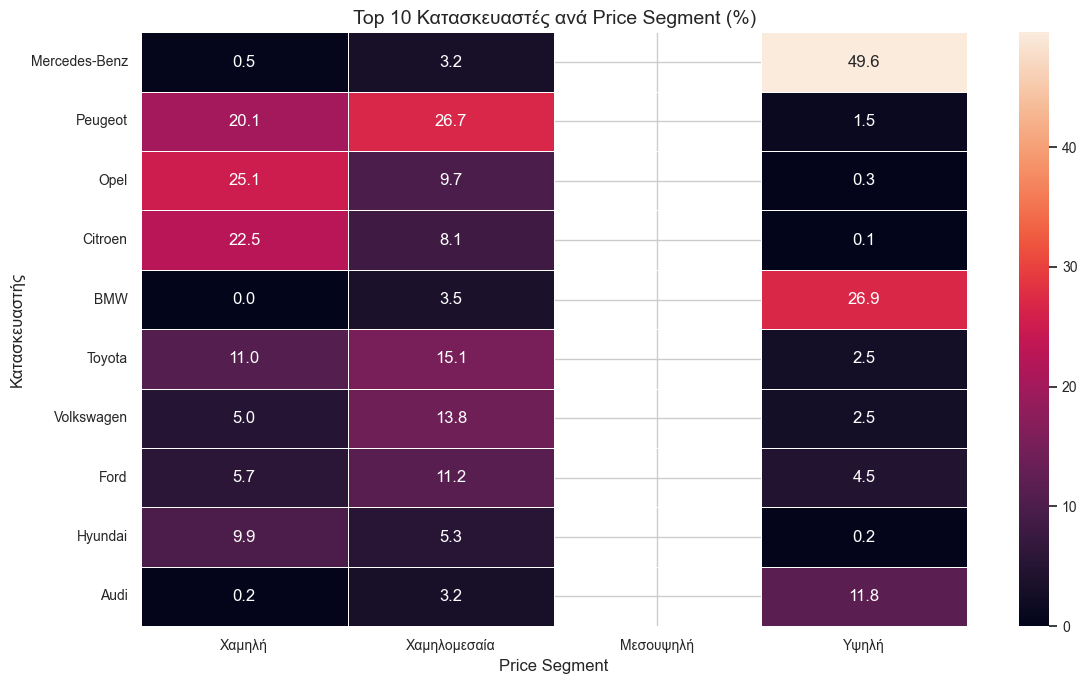

In [21]:
# ===============================
# Notebook 5 - Κατασκευαστής ανά price segment (Top 10 makes)
# ===============================

# ---------------------------------
# 1. Επιλογή Top 10 κατασκευαστών
# ---------------------------------

top_10_makes = analysis_df["make"].value_counts().head(10).index.tolist()

make_top10_df = analysis_df[
    analysis_df["make"].isin(top_10_makes)
].copy()

print("Top 10 κατασκευαστές του analytical sample:")
print(top_10_makes)

# Σταθερή σειρά segments για καθαρότερη παρουσίαση
segment_order = ["Χαμηλή", "Χαμηλομεσαία", "Μεσουψηλή", "Υψηλή"]

# ---------------------------------
# 2. Πίνακας counts
# ---------------------------------

make_counts = pd.crosstab(
    make_top10_df["price_segment"],
    make_top10_df["make"]
)

# Ταξινόμηση γραμμών και στηλών
make_counts = make_counts.reindex(segment_order)
make_counts = make_counts.loc[:, make_counts.sum().sort_values(ascending=False).index]

print("\nΠλήθος αγγελιών ανά top-10 κατασκευαστή και price_segment:")
display(make_counts)

export_csv(
    make_counts.reset_index(),
    "notebook5_top10_make_by_segment_counts.csv"
)

# ---------------------------------
# 3. Ποσοστά εντός segment
# ---------------------------------

make_shares = pd.crosstab(
    make_top10_df["price_segment"],
    make_top10_df["make"],
    normalize="index"
) * 100

make_shares = make_shares.reindex(segment_order)
make_shares = make_shares.loc[:, make_counts.columns].round(2)

print("\nΠοσοστιαία σύνθεση top-10 κατασκευαστών μέσα σε κάθε price segment:")
display(make_shares)

export_csv(
    make_shares.reset_index(),
    "notebook5_top10_make_by_segment_shares.csv"
)

# ---------------------------------
# 4. Heatmap ποσοστών
# ---------------------------------

plt.figure(figsize=(12, 7))

sns.heatmap(
    make_shares.T,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Top 10 Κατασκευαστές ανά Price Segment (%)")
plt.xlabel("Price Segment")
plt.ylabel("Κατασκευαστής")

save_plot("notebook5_top10_make_by_segment_heatmap.png")

plt.show()

In [22]:
print("Μοναδικές τιμές price_segment:")
print(sorted(analysis_df["price_segment"].dropna().unique().tolist()))

Μοναδικές τιμές price_segment:
['Μεσοϋψηλή', 'Υψηλή', 'Χαμηλή', 'Χαμηλομεσαία']


Top 10 κατασκευαστές του analytical sample:
['Mercedes-Benz', 'Peugeot', 'BMW', 'Toyota', 'Opel', 'Volkswagen', 'Citroen', 'Ford', 'Audi', 'Hyundai']

Πλήθος αγγελιών ανά top-10 κατασκευαστή και price_segment:


make,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
price_segment,,,,,,,,,,
Χαμηλή,6,262,0,143,326,65,293,74,3,129
Χαμηλομεσαία,45,371,49,210,135,191,113,156,45,73
Μεσουψηλή,0,0,0,0,0,0,0,0,0,0
Υψηλή,644,19,350,33,4,33,1,59,153,3


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_top10_make_by_segment_counts.csv

Ποσοστιαία σύνθεση top-10 κατασκευαστών μέσα σε κάθε price segment:


make,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
price_segment,,,,,,,,,,
Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
Μεσουψηλή,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook5_top10_make_by_segment_shares.csv
Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_top10_make_by_segment_heatmap.png


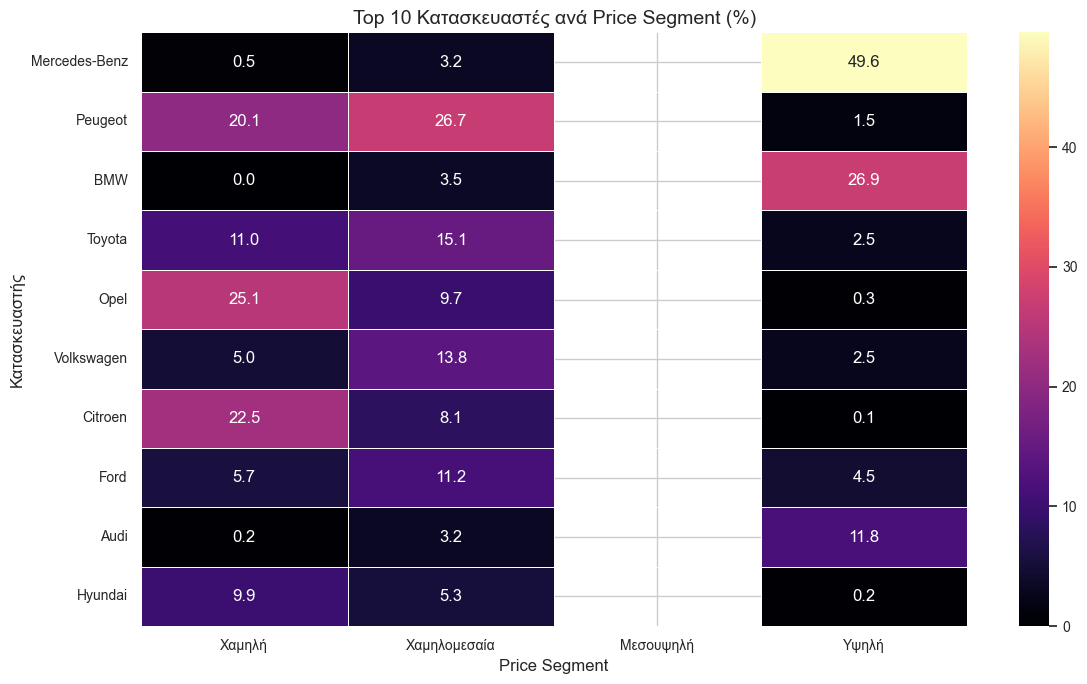

In [23]:
# ============================================================
# Κατασκευαστής ανά price segment (robust version)
# ============================================================

# Καθαρισμός price_segment για αποφυγή hidden χαρακτήρων / κενών
analysis_df["price_segment"] = (
    analysis_df["price_segment"]
    .astype(str)
    .str.replace("\u00a0", " ", regex=False)
    .str.replace("\u200b", "", regex=False)
    .str.strip()
)

# Σταθερή σειρά segments
segment_order = ["Χαμηλή", "Χαμηλομεσαία", "Μεσουψηλή", "Υψηλή"]

analysis_df["price_segment"] = pd.Categorical(
    analysis_df["price_segment"],
    categories=segment_order,
    ordered=True
)

# Top-10 κατασκευαστές στο analytical sample
top10_makes = analysis_df["make"].value_counts().head(10).index.tolist()

print("Top 10 κατασκευαστές του analytical sample:")
print(top10_makes)

# Πλήθος αγγελιών ανά segment και κατασκευαστή
make_segment_counts = (
    analysis_df.loc[analysis_df["make"].isin(top10_makes), ["price_segment", "make"]]
    .groupby(["price_segment", "make"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=segment_order, columns=top10_makes, fill_value=0)
)

print("\nΠλήθος αγγελιών ανά top-10 κατασκευαστή και price_segment:")
display(make_segment_counts)

export_csv(make_segment_counts.reset_index(), "notebook5_top10_make_by_segment_counts.csv")

# Ποσοστιαία σύνθεση μέσα σε κάθε segment
make_segment_shares = (
    make_segment_counts
    .div(make_segment_counts.sum(axis=1), axis=0)
    .multiply(100)
    .round(2)
)

print("\nΠοσοστιαία σύνθεση top-10 κατασκευαστών μέσα σε κάθε price segment:")
display(make_segment_shares)

export_csv(make_segment_shares.reset_index(), "notebook5_top10_make_by_segment_shares.csv")

# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    make_segment_shares.T,
    annot=True,
    fmt=".1f",
    cmap="magma",
    linewidths=0.5
)

plt.title("Top 10 Κατασκευαστές ανά Price Segment (%)")
plt.xlabel("Price Segment")
plt.ylabel("Κατασκευαστής")

save_plot("notebook5_top10_make_by_segment_heatmap.png")
plt.show()

In [24]:
print("Μοναδικά price segments:")
print(analysis_df["price_segment"].astype(str).str.strip().unique())

print("\nΚατανομή price_segment:")
print(analysis_df["price_segment"].astype(str).str.strip().value_counts(dropna=False))

print("\nTop κατασκευαστές μόνο για Μεσοϋψηλή:")
print(
    analysis_df.loc[
        analysis_df["price_segment"].astype(str).str.strip() == "Μεσοϋψηλή",
        "make"
    ].value_counts().head(15)
)

Μοναδικά price segments:
<ArrowStringArray>
[nan, 'Υψηλή', 'Χαμηλομεσαία', 'Χαμηλή']
Length: 4, dtype: str

Κατανομή price_segment:
price_segment
Χαμηλομεσαία    2081
Χαμηλή          2077
NaN             2069
Υψηλή           2069
Name: count, dtype: int64

Top κατασκευαστές μόνο για Μεσοϋψηλή:
Series([], Name: count, dtype: int64)


In [25]:
segment_order = ["Χαμηλή", "Χαμηλομεσαία", "Μεσοϋψηλή", "Υψηλή"]

analysis_df["price_segment"] = (
    analysis_df["price_segment"]
    .astype(str)
    .str.strip()
)

analysis_df["price_segment"] = pd.Categorical(
    analysis_df["price_segment"],
    categories=segment_order,
    ordered=True
)

top10_makes = analysis_df["make"].value_counts().head(10).index.tolist()

make_segment_counts = (
    pd.crosstab(analysis_df["price_segment"], analysis_df["make"])
    .reindex(index=segment_order, fill_value=0)
    .reindex(columns=top10_makes, fill_value=0)
)

make_segment_shares = (
    make_segment_counts.div(make_segment_counts.sum(axis=1), axis=0) * 100
).round(2)

display(make_segment_counts)
display(make_segment_shares)

make,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
price_segment,,,,,,,,,,
Χαμηλή,6,262,0,143,326,65,293,74,3,129
Χαμηλομεσαία,45,371,49,210,135,191,113,156,45,73
Μεσοϋψηλή,0,0,0,0,0,0,0,0,0,0
Υψηλή,644,19,350,33,4,33,1,59,153,3


make,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
price_segment,,,,,,,,,,
Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
Μεσοϋψηλή,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23


Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook5_top10_make_by_segment_heatmap.png


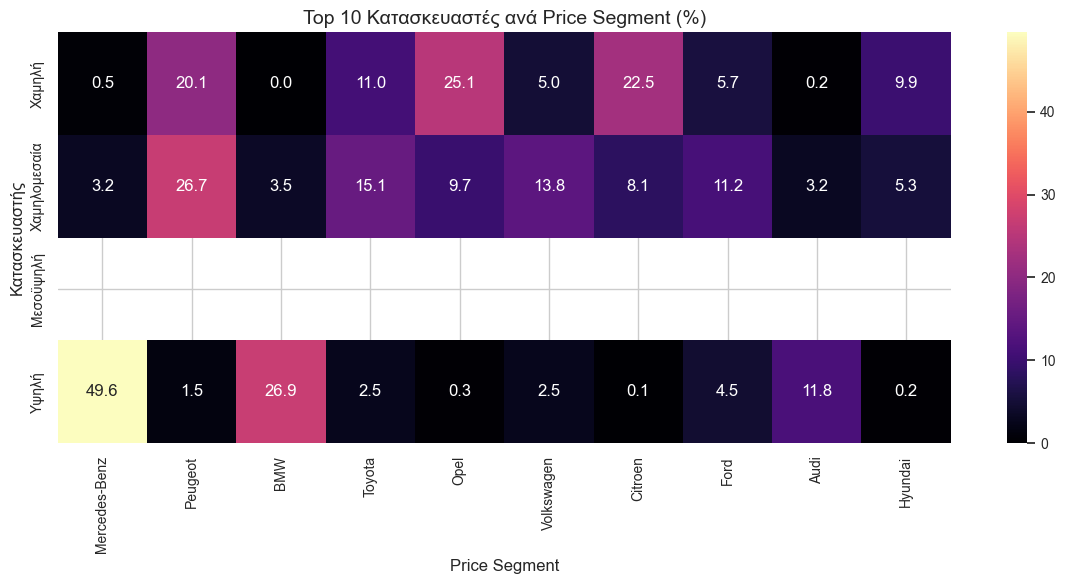

In [26]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    make_segment_shares,
    annot=True,
    fmt=".1f",
    cmap="magma",
    cbar=True
)
plt.title("Top 10 Κατασκευαστές ανά Price Segment (%)")
plt.xlabel("Price Segment")
plt.ylabel("Κατασκευαστής")

save_plot("notebook5_top10_make_by_segment_heatmap.png")
plt.show()

## Συνολικά Συμπεράσματα Notebook 5

Η αγορά μεταχειρισμένων αυτοκινήτων στην Αττική εμφανίζει έντονη δεξιά ασυμμετρία και σημαντική εσωτερική ετερογένεια ως προς την τιμή. Η quantile-based τμηματοποίηση παρήγαγε τέσσερα ισορροπημένα price segments, επιτρέποντας σταθερές και συγκρίσιμες αναλύσεις μεταξύ επιμέρους ζωνών τιμολόγησης.

Η σύγκριση των segments έδειξε ότι τα ακριβότερα οχήματα δεν διαφέρουν μόνο ως προς την τιμή, αλλά και ως προς το συνολικό τους προφίλ: συνδέονται με χαμηλότερα χιλιόμετρα, ισχυρότερη ιπποδύναμη, μεγαλύτερο κυβισμό, αυξημένη παρουσία αυτόματης μετάδοσης και μεγαλύτερη συμμετοχή εξηλεκτρισμένων τεχνολογιών. Αντίθετα, τα χαμηλότερα segments συγκεντρώνουν οχήματα πιο συμβατικού προφίλ, με υψηλότερη χρήση και πιο περιορισμένα τεχνικά χαρακτηριστικά.

Συνεπώς, τα price segments που προέκυψαν αποτυπώνουν ουσιαστικές υποαγορές της αγοράς μεταχειρισμένων και αποτελούν κατάλληλη βάση για τα επόμενα στάδια της ανάλυσης και της ερμηνείας της δομής της αγοράς.